<a href="https://colab.research.google.com/github/Ashu-42/quant_research_crypto_volatility_forecasting/blob/quant_DL_ashu/notebooks/15min/07_Intraday_Final_Holistic_Comparison_Train_Validation_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 07 — Final Intraday Holistic Model Comparison: Train / Validation / Test

This is the **final evaluation notebook** for the 15-minute volatility-forecasting branch.

All model specifications have already been frozen in the earlier notebooks. This notebook **does not tune or retrain the deep-learning models**. It loads the saved final models/scalers and evaluates them on a common, dynamically constructed set of target timestamps.

**Interpretation:** Train metrics are in-sample fit diagnostics for the frozen models. Validation and Test are the out-of-sample evaluation splits; Test is the final untouched holdout.

## Primary target

\[
RV_{t+1}=r_{t+1}^{2}
\]

where \(r_{t+1}\) is the next-candle close-to-close log return.

## Models included

### Predictive baselines
- Persistence
- every rolling-mean-RV baseline defined by Notebook 02
- same target clock slot on the previous day
- Train-only target-slot mean RV
- **causal rolling standard deviation of returns** (configurable duration)

### ARCH family
- GARCH(1,1)
- GJR-GARCH(1,1)
- EGARCH(1,1)

### Deep learning
- Asset-Specific MLP
- Global MLP
- Asset-Specific GRU
- Global GRU
- Asset-Specific LSTM
- Global LSTM

## Two distinct rolling-standard-deviation uses

1. **Causal rolling-std baseline** — uses returns available only through the forecast origin and is scored as a predictive model.
2. **Ex-post rolling-std proxy** — includes the realized target candle and is used only as a robustness / visualization reference. It is never used as a feature or for model selection.

## Test-set policy

Validation reproduction is checked first against the already-saved Validation prediction artifacts. **Only after those checks pass is the held-out Test period evaluated.**

Once Test results have been viewed, do not tune the current model specifications further. Any new model development should use a new holdout period.

## 1. Imports, packages and Drive

In [1]:
from google.colab import drive
from pathlib import Path
from datetime import datetime, timezone

import gc
import importlib.metadata
import importlib.util
import json
import math
import os
import subprocess
import sys
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import Dense

ARCH_VERSION = "7.2.0"

installed_arch = None
if importlib.util.find_spec("arch") is not None:
    try:
        installed_arch = importlib.metadata.version("arch")
    except Exception:
        installed_arch = None

if installed_arch != ARCH_VERSION:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        f"arch=={ARCH_VERSION}",
    ])

from arch import arch_model

drive.mount("/content/drive")

print("TensorFlow:", tf.__version__)
print("arch:", importlib.metadata.version("arch"))

Mounted at /content/drive
TensorFlow: 2.20.0
arch: 7.2.0


## 2. Configuration

In [2]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Quant Research/15min"
)

# Only PROJECT_ROOT is experiment-specific. The candle interval is discovered
# from the unique Notebook 02 processing manifest below, so changing to another
# prepared experiment folder does not require editing interval-dependent logic.
MANIFEST_BASE = PROJECT_ROOT / "manifests"

processing_manifest_candidates = sorted(
    MANIFEST_BASE.glob("*/processing_manifest_*_v*.json")
)

if len(processing_manifest_candidates) != 1:
    raise FileNotFoundError(
        "Expected exactly one Notebook 02 processing manifest under "
        f"{MANIFEST_BASE}; found {len(processing_manifest_candidates)}.\n"
        + "\n".join(str(path) for path in processing_manifest_candidates)
    )

PROCESSING_MANIFEST_PATH = processing_manifest_candidates[0]
processing_manifest = json.loads(
    PROCESSING_MANIFEST_PATH.read_text(encoding="utf-8")
)

KLINE_INTERVAL = str(processing_manifest["kline_interval"])
MANIFEST_ROOT = PROCESSING_MANIFEST_PATH.parent

SYMBOLS = [
    "BTCUSDT",
    "ETHUSDT",
    "SOLUSDT",
    "XRPUSDT",
]

ASSET_LABELS = {
    "BTCUSDT": "BTC",
    "ETHUSDT": "ETH",
    "SOLUSDT": "SOL",
    "XRPUSDT": "XRP",
}

ASSET_TO_INDEX = {
    symbol: index
    for index, symbol in enumerate(SYMBOLS)
}

N_ASSETS = len(SYMBOLS)

EPSILON = 1e-12
RETURN_SCALE = 100.0
PREDICTION_BATCH_SIZE = 4096
RECURRENT_BATCH_SIZE = 2048

# Predictive rolling-standard-deviation baseline.
# This ends at the forecast origin and therefore uses no target information.
ROLLING_STD_BASELINE_DURATION = "1d"

# Ex-post robustness proxies. These include the target observation and are
# never used for training or model selection. Durations are converted to bars
# from the discovered interval at runtime.
ROLLING_PROXY_DURATIONS = [
    "4h",
    "12h",
    "1d",
]

# Test volatility chart window.
PLOT_WINDOW_DURATION = "7d"
PLOT_START = None

# This is the final evaluation notebook. Set False only if you want to
# reproduce Validation without opening Test yet.
EVALUATE_TEST = True

MODEL_READY_ROOT = (
    PROJECT_ROOT
    / "data"
    / "model_ready"
    / KLINE_INTERVAL
)

RESULTS_ROOT = (
    PROJECT_ROOT
    / "results"
    / KLINE_INTERVAL
)

FINAL_RESULTS_ROOT = (
    RESULTS_ROOT
    / "FINAL_HOLISTIC_COMPARISON"
)

FIGURE_ROOT = (
    FINAL_RESULTS_ROOT
    / "figures"
)

for directory in [
    FINAL_RESULTS_ROOT,
    FIGURE_ROOT,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project:", PROJECT_ROOT)
print("Discovered manifest:", PROCESSING_MANIFEST_PATH)
print("Discovered interval:", KLINE_INTERVAL)
print("Final output:", FINAL_RESULTS_ROOT)
print("EVALUATE_TEST:", EVALUATE_TEST)


Project: /content/drive/MyDrive/Quant Research/15min
Discovered manifest: /content/drive/MyDrive/Quant Research/15min/manifests/15m/processing_manifest_15m_v1.json
Discovered interval: 15m
Final output: /content/drive/MyDrive/Quant Research/15min/results/15m/FINAL_HOLISTIC_COMPARISON
EVALUATE_TEST: True


## 3. Load Notebook 02 processing manifest and canonical data

In [3]:
if processing_manifest["kline_interval"] != KLINE_INTERVAL:
    raise ValueError("Processing-manifest interval mismatch.")

INTERVAL_MINUTES = int(processing_manifest["interval_minutes"])
INTERVAL_DELTA = pd.Timedelta(minutes=INTERVAL_MINUTES)
BARS_PER_DAY = int(processing_manifest["bars_per_day"])

ROLLING_RV_HORIZONS = dict(
    processing_manifest["rolling_rv_horizons"]
)

split_config = processing_manifest["split_boundaries_utc"]

VALIDATION_START = pd.Timestamp(
    split_config["validation_target_start"]
)
TEST_START = pd.Timestamp(
    split_config["validation_target_end_exclusive"]
)
TEST_END_EXCLUSIVE = pd.Timestamp(
    split_config["test_target_end_exclusive"]
)

FULL_FEATURES_PATH = Path(
    processing_manifest["outputs"]["full_features_parquet"]
)
MODEL_ROWS_PATH = Path(
    processing_manifest["outputs"]["valid_model_rows_parquet"]
)
SEASONALITY_PATH = Path(
    processing_manifest["outputs"]["seasonality_factors_parquet"]
)

for path in [
    FULL_FEATURES_PATH,
    MODEL_ROWS_PATH,
    SEASONALITY_PATH,
]:
    if not path.exists():
        raise FileNotFoundError(path)

features_df = pd.read_parquet(FULL_FEATURES_PATH)
model_rows_df = pd.read_parquet(MODEL_ROWS_PATH)
seasonality_df = pd.read_parquet(SEASONALITY_PATH)

for frame in [features_df, model_rows_df]:
    frame["open_time"] = pd.to_datetime(
        frame["open_time"], utc=True, errors="raise"
    )
    frame["target_open_time"] = pd.to_datetime(
        frame["target_open_time"], utc=True, errors="coerce"
    )

required_model_columns = {
    "symbol",
    "open_time",
    "target_open_time",
    "split",
    "realized_variance",
    "target_realized_variance",
    "target_slot_index",
    *ROLLING_RV_HORIZONS.keys(),
}

missing = required_model_columns - set(model_rows_df.columns)
if missing:
    raise ValueError(f"Canonical model rows missing columns: {missing}")

assert model_rows_df["target_open_time"].sub(
    model_rows_df["open_time"]
).eq(INTERVAL_DELTA).all()

EXPECTED_VALIDATION_ROWS = int(
    (TEST_START - VALIDATION_START) / INTERVAL_DELTA
)
EXPECTED_TEST_ROWS = int(
    (TEST_END_EXCLUSIVE - TEST_START) / INTERVAL_DELTA
)

print("Interval:", INTERVAL_DELTA)
print("Bars/day:", BARS_PER_DAY)
print("Validation:", VALIDATION_START, "to", TEST_START)
print("Test:", TEST_START, "to", TEST_END_EXCLUSIVE)
print("Expected validation rows/asset:", EXPECTED_VALIDATION_ROWS)
print("Expected test rows/asset:", EXPECTED_TEST_ROWS)

Interval: 0 days 00:15:00
Bars/day: 96
Validation: 2024-08-01 00:00:00+00:00 to 2025-08-01 00:00:00+00:00
Test: 2025-08-01 00:00:00+00:00 to 2026-08-01 00:00:00+00:00
Expected validation rows/asset: 35040
Expected test rows/asset: 35040


## 4. Dynamic duration helpers

In [4]:
def duration_to_bars(duration):
    duration_td = pd.Timedelta(duration)

    if duration_td < INTERVAL_DELTA:
        raise ValueError(
            f"{duration} is shorter than interval {INTERVAL_DELTA}."
        )

    if int(duration_td.value) % int(INTERVAL_DELTA.value) != 0:
        raise ValueError(
            f"{duration} is not exactly representable at {KLINE_INTERVAL}."
        )

    return int(duration_td / INTERVAL_DELTA)


def duration_tag(duration):
    return str(duration).replace(" ", "").replace(":", "_")


ROLLING_STD_BASELINE_BARS = duration_to_bars(
    ROLLING_STD_BASELINE_DURATION
)

ROLLING_PROXY_BARS = {
    duration: duration_to_bars(duration)
    for duration in ROLLING_PROXY_DURATIONS
}

print(
    "Causal rolling-std baseline:",
    ROLLING_STD_BASELINE_DURATION,
    "=",
    ROLLING_STD_BASELINE_BARS,
    "bars",
)

print("Ex-post rolling proxies:", ROLLING_PROXY_BARS)

Causal rolling-std baseline: 1d = 96 bars
Ex-post rolling proxies: {'4h': 16, '12h': 48, '1d': 96}


## 5. Load frozen DL feature manifests and artifacts

In [5]:
MLP_FEATURE_MANIFEST_PATH = (
    MANIFEST_ROOT
    / f"mlp_final_state_features_{KLINE_INTERVAL}_manifest.json"
)
GRU_FEATURE_MANIFEST_PATH = (
    MANIFEST_ROOT
    / f"gru_final_enhanced_features_{KLINE_INTERVAL}_manifest.json"
)
LSTM_FEATURE_MANIFEST_PATH = (
    MANIFEST_ROOT
    / f"lstm_final_enhanced_features_{KLINE_INTERVAL}_manifest.json"
)

for path in [
    MLP_FEATURE_MANIFEST_PATH,
    GRU_FEATURE_MANIFEST_PATH,
    LSTM_FEATURE_MANIFEST_PATH,
]:
    if not path.exists():
        raise FileNotFoundError(path)

mlp_manifest = json.loads(
    MLP_FEATURE_MANIFEST_PATH.read_text(encoding="utf-8")
)
gru_manifest = json.loads(
    GRU_FEATURE_MANIFEST_PATH.read_text(encoding="utf-8")
)
lstm_manifest = json.loads(
    LSTM_FEATURE_MANIFEST_PATH.read_text(encoding="utf-8")
)

MLP_FEATURE_COLUMNS = list(
    mlp_manifest["selected_feature_columns"]
)

GRU_STATE_FEATURES = list(gru_manifest["state_features"])
GRU_SEQUENCE_FEATURES = list(gru_manifest["sequence_features"])
GRU_LOOKBACK_DURATION = str(gru_manifest["selected_duration"])
GRU_LOOKBACK_BARS = int(gru_manifest["selected_bars"])

LSTM_STATE_FEATURES = list(lstm_manifest["state_features"])
LSTM_SEQUENCE_FEATURES = list(lstm_manifest["sequence_features"])
LSTM_LOOKBACK_DURATION = str(lstm_manifest["selected_duration"])
LSTM_LOOKBACK_BARS = int(lstm_manifest["selected_bars"])

if duration_to_bars(GRU_LOOKBACK_DURATION) != GRU_LOOKBACK_BARS:
    raise ValueError("GRU duration/bar mismatch in saved manifest.")

if duration_to_bars(LSTM_LOOKBACK_DURATION) != LSTM_LOOKBACK_BARS:
    raise ValueError("LSTM duration/bar mismatch in saved manifest.")

MLP_FEATURE_PATH = Path(mlp_manifest["output_path"])
GRU_FEATURE_PATH = Path(gru_manifest["output_path"])
LSTM_FEATURE_PATH = Path(lstm_manifest["output_path"])

for path in [
    MLP_FEATURE_PATH,
    GRU_FEATURE_PATH,
    LSTM_FEATURE_PATH,
]:
    if not path.exists():
        raise FileNotFoundError(path)

mlp_feature_df = pd.read_parquet(MLP_FEATURE_PATH)
gru_feature_df = pd.read_parquet(GRU_FEATURE_PATH)
lstm_feature_df = pd.read_parquet(LSTM_FEATURE_PATH)

for frame in [mlp_feature_df, gru_feature_df, lstm_feature_df]:
    frame["open_time"] = pd.to_datetime(
        frame["open_time"], utc=True, errors="raise"
    )
    frame["target_open_time"] = pd.to_datetime(
        frame["target_open_time"], utc=True, errors="raise"
    )

print("MLP features:", len(MLP_FEATURE_COLUMNS))
print("GRU:", GRU_LOOKBACK_DURATION, GRU_LOOKBACK_BARS, "bars")
print("LSTM:", LSTM_LOOKBACK_DURATION, LSTM_LOOKBACK_BARS, "bars")

MLP features: 48
GRU: 4h 16 bars
LSTM: 12h 48 bars


## 6. Canonical-key filtering and recurrent sequence availability

In [6]:
canonical_keys = model_rows_df[
    [
        "symbol",
        "target_open_time",
        "split",
        "target_realized_variance",
    ]
].drop_duplicates(["symbol", "target_open_time"])

# MLP final artifact was saved from the enhanced full table. Restrict the
# evaluation set explicitly to Notebook 02 canonical one-candle targets.
mlp_feature_df = (
    mlp_feature_df
    .merge(
        canonical_keys[["symbol", "target_open_time"]],
        on=["symbol", "target_open_time"],
        how="inner",
        validate="one_to_one",
    )
    .sort_values(["symbol", "open_time"])
    .reset_index(drop=True)
)


def build_recurrent_frames_and_maps(feature_df, lookback_bars):
    frames = {}
    maps = {}

    for symbol in SYMBOLS:
        frame = (
            feature_df.loc[feature_df["symbol"].eq(symbol)]
            .sort_values("open_time")
            .reset_index(drop=True)
            .copy()
        )

        if frame.duplicated("open_time").any():
            raise ValueError(f"{symbol}: duplicate recurrent feature times.")

        start_time = frame["open_time"].shift(lookback_bars - 1)
        exact_span = frame["open_time"].sub(start_time).eq(
            (lookback_bars - 1) * INTERVAL_DELTA
        )

        valid_end_indices = np.flatnonzero(
            exact_span.to_numpy(bool)
            & frame["split"].isin(["train", "validation", "test"])
            .to_numpy(bool)
        )

        target_to_end = {
            frame.loc[int(index), "target_open_time"]: int(index)
            for index in valid_end_indices
        }

        frames[symbol] = frame
        maps[symbol] = target_to_end

    return frames, maps


gru_frames, gru_target_to_end = build_recurrent_frames_and_maps(
    gru_feature_df,
    GRU_LOOKBACK_BARS,
)

lstm_frames, lstm_target_to_end = build_recurrent_frames_and_maps(
    lstm_feature_df,
    LSTM_LOOKBACK_BARS,
)

print("Recurrent sequence availability constructed.")

Recurrent sequence availability constructed.


## 7. Build causal and ex-post rolling standard deviations

In [7]:
def strict_rolling_std(values, times, bars, ddof=1):
    rolling_std = values.rolling(
        bars,
        min_periods=bars,
    ).std(ddof=ddof)

    count = values.rolling(
        bars,
        min_periods=bars,
    ).count()

    start_time = times.shift(bars - 1)
    exact_span = times.sub(start_time).eq(
        (bars - 1) * INTERVAL_DELTA
    )

    return rolling_std.where(
        count.eq(bars) & exact_span
    )


rolling_origin_parts = []
rolling_proxy_parts = []

all_proxy_bars = {
    "__causal__": ROLLING_STD_BASELINE_BARS,
    **ROLLING_PROXY_BARS,
}

for symbol in SYMBOLS:
    history = (
        features_df.loc[
            features_df["symbol"].eq(symbol),
            ["symbol", "open_time", "return"],
        ]
        .sort_values("open_time")
        .drop_duplicates("open_time")
        .copy()
    )

    # Causal baseline is measured at forecast origin t.
    history["causal_rolling_std"] = strict_rolling_std(
        history["return"].astype(float),
        history["open_time"],
        ROLLING_STD_BASELINE_BARS,
    )

    rolling_origin_parts.append(
        history[["symbol", "open_time", "causal_rolling_std"]]
    )

    proxy = history[["symbol", "open_time"]].copy()
    proxy = proxy.rename(columns={"open_time": "target_open_time"})

    for duration, bars in ROLLING_PROXY_BARS.items():
        proxy[f"proxy_std_{duration_tag(duration)}"] = strict_rolling_std(
            history["return"].astype(float),
            history["open_time"],
            bars,
        ).to_numpy()

    rolling_proxy_parts.append(proxy)

rolling_origin_df = pd.concat(rolling_origin_parts, ignore_index=True)
rolling_proxy_df = pd.concat(rolling_proxy_parts, ignore_index=True)

print("Rolling standard deviations constructed.")

Rolling standard deviations constructed.


## 8. Build all predictive baseline columns

In [8]:
baseline_base_df = model_rows_df[
    [
        "symbol",
        "open_time",
        "target_open_time",
        "split",
        "target_realized_variance",
        "realized_variance",
        "target_slot_index",
        *ROLLING_RV_HORIZONS.keys(),
    ]
].copy()

baseline_base_df = baseline_base_df.merge(
    rolling_origin_df,
    on=["symbol", "open_time"],
    how="left",
    validate="one_to_one",
)

baseline_base_df["rolling_std_predicted_variance"] = (
    baseline_base_df["causal_rolling_std"].astype(float) ** 2
)

# Previous-day same target slot.
historical_rv_lookup = (
    features_df[["symbol", "open_time", "realized_variance"]]
    .dropna(subset=["realized_variance"])
    .rename(columns={
        "open_time": "historical_open_time",
        "realized_variance": "same_slot_previous_day_variance",
    })
)

baseline_base_df["historical_open_time"] = (
    baseline_base_df["target_open_time"] - pd.Timedelta(days=1)
)

baseline_base_df = baseline_base_df.merge(
    historical_rv_lookup,
    on=["symbol", "historical_open_time"],
    how="left",
    validate="many_to_one",
)

slot_mean_lookup = seasonality_df[
    ["symbol", "slot_index", "mean_rv"]
].rename(columns={
    "slot_index": "target_slot_index",
    "mean_rv": "train_slot_mean_variance",
})

baseline_base_df = baseline_base_df.merge(
    slot_mean_lookup,
    on=["symbol", "target_slot_index"],
    how="left",
    validate="many_to_one",
)

BASELINE_SPECS = [
    ("Persistence", "realized_variance"),
]

for feature_name, duration in ROLLING_RV_HORIZONS.items():
    BASELINE_SPECS.append((f"Mean RV ({duration})", feature_name))

BASELINE_SPECS += [
    ("Same Slot Previous Day", "same_slot_previous_day_variance"),
    ("Train Slot Mean RV", "train_slot_mean_variance"),
    (
        f"Rolling Std ({ROLLING_STD_BASELINE_DURATION}, causal)",
        "rolling_std_predicted_variance",
    ),
]

print("Predictive baseline models:")
for model_name, column in BASELINE_SPECS:
    print(" -", model_name, "<-", column)

Predictive baseline models:
 - Persistence <- realized_variance
 - Mean RV (4h) <- rv_mean_4h
 - Mean RV (1d) <- rv_mean_24h
 - Same Slot Previous Day <- same_slot_previous_day_variance
 - Train Slot Mean RV <- train_slot_mean_variance
 - Rolling Std (1d, causal) <- rolling_std_predicted_variance


## 9. ARCH return history using frozen Train seasonality

In [9]:
def add_slot_index(frame, timestamp_column):
    output = frame.copy()
    minute_of_day = (
        output[timestamp_column].dt.hour * 60
        + output[timestamp_column].dt.minute
    )
    output["slot_index"] = (
        minute_of_day // INTERVAL_MINUTES
    ).astype(int)
    return output


return_history_df = (
    features_df[["symbol", "open_time", "return"]]
    .dropna(subset=["return"])
    .copy()
)

return_history_df = add_slot_index(return_history_df, "open_time")

seasonality_lookup = seasonality_df[
    ["symbol", "slot_index", "variance_seasonality_factor"]
].copy()

return_history_df = return_history_df.merge(
    seasonality_lookup,
    on=["symbol", "slot_index"],
    how="left",
    validate="many_to_one",
)

if return_history_df["variance_seasonality_factor"].isna().any():
    raise ValueError("ARCH return history has missing seasonality factors.")

return_history_df["deseasonalized_return"] = (
    return_history_df["return"].astype(float)
    / np.sqrt(return_history_df["variance_seasonality_factor"].astype(float))
)

ARCH_SPECS = {
    "GARCH(1,1)": {"vol": "GARCH", "p": 1, "o": 0, "q": 1},
    "GJR-GARCH(1,1)": {"vol": "GARCH", "p": 1, "o": 1, "q": 1},
    "EGARCH(1,1)": {"vol": "EGARCH", "p": 1, "o": 1, "q": 1},
}

print("ARCH return history ready.")

ARCH return history ready.


## 10. Construct common evaluation timestamps before generating forecasts

In [10]:
# Availability of each baseline row.
baseline_available_df = baseline_base_df.copy()

baseline_required_columns = [
    column
    for _, column in BASELINE_SPECS
]

baseline_available_df["all_baselines_available"] = (
    baseline_available_df[baseline_required_columns]
    .notna()
    .all(axis=1)
)

mlp_available = {
    symbol: {
        split: set(
            mlp_feature_df.loc[
                mlp_feature_df["symbol"].eq(symbol)
                & mlp_feature_df["split"].eq(split),
                "target_open_time",
            ]
        )
        for split in ["train", "validation", "test"]
    }
    for symbol in SYMBOLS
}

arch_available = {
    symbol: set(
        return_history_df.loc[
            return_history_df["symbol"].eq(symbol),
            "open_time",
        ]
    )
    for symbol in SYMBOLS
}

common_dates = {
    symbol: {}
    for symbol in SYMBOLS
}

common_date_rows = []

for symbol in SYMBOLS:
    for split in ["train", "validation", "test"]:
        canonical = set(
            model_rows_df.loc[
                model_rows_df["symbol"].eq(symbol)
                & model_rows_df["split"].eq(split),
                "target_open_time",
            ]
        )

        baseline_set = set(
            baseline_available_df.loc[
                baseline_available_df["symbol"].eq(symbol)
                & baseline_available_df["split"].eq(split)
                & baseline_available_df["all_baselines_available"],
                "target_open_time",
            ]
        )

        gru_set = {
            timestamp
            for timestamp in gru_target_to_end[symbol]
            if timestamp in canonical
        }

        lstm_set = {
            timestamp
            for timestamp in lstm_target_to_end[symbol]
            if timestamp in canonical
        }

        sets = [
            canonical,
            baseline_set,
            mlp_available[symbol][split],
            gru_set,
            lstm_set,
            arch_available[symbol],
        ]

        common = sorted(set.intersection(*sets))

        if len(common) < 1000:
            raise ValueError(
                f"{symbol} {split}: insufficient common evaluation dates "
                f"({len(common)})."
            )

        common_dates[symbol][split] = pd.DatetimeIndex(common)

        common_date_rows.append({
            "symbol": symbol,
            "split": split,
            "observations": len(common),
            "first_target": min(common),
            "last_target": max(common),
        })

common_date_qc_df = pd.DataFrame(common_date_rows)
display(common_date_qc_df)

# Validation should remain the exact official one-year grid used previously.
validation_qc = common_date_qc_df.loc[
    common_date_qc_df["split"].eq("validation")
]

assert validation_qc["observations"].eq(EXPECTED_VALIDATION_ROWS).all()
assert validation_qc["first_target"].eq(VALIDATION_START).all()
assert validation_qc["last_target"].eq(TEST_START - INTERVAL_DELTA).all()

print("Common evaluation-date construction passed.")

,symbol,split,observations,first_target,last_target
0,BTCUSDT,train,238464,2017-08-18 16:00:00+00:00,2024-07-31 23:45:00+00:00
1,BTCUSDT,validation,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
2,BTCUSDT,test,35040,2025-08-01 00:00:00+00:00,2026-07-31 23:45:00+00:00
3,ETHUSDT,train,238464,2017-08-18 16:00:00+00:00,2024-07-31 23:45:00+00:00
4,ETHUSDT,validation,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
5,ETHUSDT,test,35040,2025-08-01 00:00:00+00:00,2026-07-31 23:45:00+00:00
6,SOLUSDT,train,137589,2020-08-12 18:00:00+00:00,2024-07-31 23:45:00+00:00
7,SOLUSDT,validation,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
8,SOLUSDT,test,35040,2025-08-01 00:00:00+00:00,2026-07-31 23:45:00+00:00
9,XRPUSDT,train,214702,2018-05-05 20:00:00+00:00,2024-07-31 23:45:00+00:00


Common evaluation-date construction passed.


## 11. Metric, alignment and prediction helpers

In [11]:
def qlike(actual_variance, predicted_variance):
    actual = np.maximum(
        np.asarray(actual_variance, dtype=float),
        EPSILON,
    )
    predicted = np.maximum(
        np.asarray(predicted_variance, dtype=float),
        EPSILON,
    )
    ratio = actual / predicted
    return float(np.mean(ratio - np.log(ratio) - 1.0))


def metric_values(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    error = predicted - actual
    return {
        "mae": float(np.mean(np.abs(error))),
        "rmse": float(np.sqrt(np.mean(error ** 2))),
        "qlike": qlike(actual, predicted),
    }


canonical_actual_lookup = (
    model_rows_df[
        ["symbol", "target_open_time", "target_realized_variance"]
    ]
    .drop_duplicates(["symbol", "target_open_time"])
    .set_index(["symbol", "target_open_time"])["target_realized_variance"]
)


def actual_for_times(symbol, times):
    index = pd.MultiIndex.from_arrays([
        np.repeat(symbol, len(times)),
        pd.DatetimeIndex(times),
    ])
    actual = canonical_actual_lookup.reindex(index)
    if actual.isna().any():
        raise ValueError(f"{symbol}: missing canonical actual variance.")
    return actual.to_numpy(dtype=float)


def prediction_frame(symbol, split, model, family, times, predicted):
    times = pd.DatetimeIndex(times)
    predicted = np.maximum(np.asarray(predicted, dtype=float), EPSILON)

    if len(times) != len(predicted):
        raise ValueError(f"{symbol} {model} {split}: prediction length mismatch.")

    if not np.isfinite(predicted).all() or not (predicted > 0).all():
        raise ValueError(f"{symbol} {model} {split}: invalid predictions.")

    return pd.DataFrame({
        "symbol": symbol,
        "split": split,
        "target_open_time": times,
        "actual_variance": actual_for_times(symbol, times),
        "predicted_variance": predicted,
        "model": model,
        "model_family": family,
    })


def append_metric_rows(prediction_df, metric_rows):
    for (symbol, split, model, family), current in prediction_df.groupby(
        ["symbol", "split", "model", "model_family"],
        sort=False,
    ):
        values = metric_values(
            current["actual_variance"],
            current["predicted_variance"],
        )
        metric_rows.append({
            "symbol": symbol,
            "asset": ASSET_LABELS[symbol],
            "split": split.title(),
            "model": model,
            "model_family": family,
            "n_observations": len(current),
            **values,
        })


def one_hot_for_asset(symbol, n_rows):
    output = np.zeros((n_rows, N_ASSETS), dtype=np.float32)
    output[:, ASSET_TO_INDEX[symbol]] = 1.0
    return output

## 12. TemporalAttention class used to reload saved GRU/LSTM models

In [12]:
@tf.keras.utils.register_keras_serializable(package="QuantProject")
class TemporalAttention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.score = Dense(1, activation=None, name="attention_score")

    def build(self, input_shape):
        self.score.build(input_shape)
        super().build(input_shape)

    def call(self, states):
        weights = tf.nn.softmax(self.score(states), axis=1)
        return tf.reduce_sum(states * weights, axis=1)

    def get_config(self):
        return super().get_config()


CUSTOM_OBJECTS = {
    "TemporalAttention": TemporalAttention,
    "QuantProject>TemporalAttention": TemporalAttention,
}

## 13. Baseline prediction function

In [13]:
baseline_by_symbol = {
    symbol: (
        baseline_base_df.loc[baseline_base_df["symbol"].eq(symbol)]
        .sort_values("target_open_time")
        .set_index("target_open_time")
    )
    for symbol in SYMBOLS
}


def generate_baseline_predictions(split_names):
    parts = []

    for symbol in SYMBOLS:
        indexed = baseline_by_symbol[symbol]

        for split in split_names:
            times = common_dates[symbol][split]
            rows = indexed.reindex(times)

            if rows["symbol"].isna().any():
                raise ValueError(f"{symbol} {split}: baseline reindex failed.")

            for model_name, column in BASELINE_SPECS:
                pred = rows[column].to_numpy(dtype=float)
                parts.append(
                    prediction_frame(
                        symbol,
                        split,
                        model_name,
                        "Baseline",
                        times,
                        pred,
                    )
                )

    return pd.concat(parts, ignore_index=True)

## 14. ARCH Train / Validation / Test prediction function

In [14]:
def generate_arch_predictions(split_names):
    parts = []
    diagnostic_rows = []

    for symbol in SYMBOLS:
        current = (
            return_history_df.loc[
                return_history_df["symbol"].eq(symbol)
                & return_history_df["open_time"].lt(TEST_END_EXCLUSIVE)
            ]
            .sort_values("open_time")
            .drop_duplicates("open_time")
            .copy()
        )

        train = current.loc[
            current["open_time"].lt(VALIDATION_START)
        ].copy()

        y_train = pd.Series(
            train["deseasonalized_return"].to_numpy(dtype=float)
            * RETURN_SCALE,
            index=train["open_time"],
            name="return_scaled",
        )

        y_full = pd.Series(
            current["deseasonalized_return"].to_numpy(dtype=float)
            * RETURN_SCALE,
            index=current["open_time"],
            name="return_scaled",
        )

        factor_by_time = current.set_index("open_time")[
            "variance_seasonality_factor"
        ]

        for model_name, specification in ARCH_SPECS.items():
            train_model = arch_model(
                y_train,
                mean="Constant",
                dist="t",
                rescale=False,
                **specification,
            )

            fit = train_model.fit(
                disp="off",
                show_warning=False,
                update_freq=0,
            )

            if fit.convergence_flag != 0:
                warnings.warn(
                    f"{symbol} {model_name}: convergence_flag={fit.convergence_flag}"
                )

            diagnostic_rows.append({
                "symbol": symbol,
                "model": model_name,
                "convergence_flag": int(fit.convergence_flag),
                "loglikelihood": float(fit.loglikelihood),
                "aic": float(fit.aic),
                "bic": float(fit.bic),
            })

            train_variance = (
                fit.conditional_volatility.astype(float) ** 2
                / (RETURN_SCALE ** 2)
            )
            train_variance = train_variance * factor_by_time.reindex(
                train_variance.index
            ).to_numpy(dtype=float)

            full_model = arch_model(
                y_full,
                mean="Constant",
                dist="t",
                rescale=False,
                **specification,
            )
            fixed_result = full_model.fix(fit.params)

            forecast = fixed_result.forecast(
                horizon=1,
                start=len(y_train) - 1,
                align="target",
                reindex=True,
            )

            forward_variance = (
                forecast.variance["h.1"]
                / (RETURN_SCALE ** 2)
            )

            for split in split_names:
                times = common_dates[symbol][split]

                if split == "train":
                    pred = train_variance.reindex(times)
                else:
                    deseason = forward_variance.reindex(times)
                    factor = factor_by_time.reindex(times)
                    if deseason.isna().any() or factor.isna().any():
                        raise ValueError(
                            f"{symbol} {model_name} {split}: missing ARCH forecasts."
                        )
                    pred = deseason.to_numpy(dtype=float) * factor.to_numpy(dtype=float)

                if isinstance(pred, pd.Series):
                    if pred.isna().any():
                        raise ValueError(
                            f"{symbol} {model_name} {split}: missing ARCH train values."
                        )
                    pred = pred.to_numpy(dtype=float)

                parts.append(
                    prediction_frame(
                        symbol,
                        split,
                        model_name,
                        "ARCH",
                        times,
                        pred,
                    )
                )

    return pd.concat(parts, ignore_index=True), pd.DataFrame(diagnostic_rows)

## 15. MLP prediction function using saved models and Train-only scalers

In [15]:
MLP_MODEL_ROOT = PROJECT_ROOT / "models" / KLINE_INTERVAL / "MLP_FINAL"
MLP_ARTIFACT_ROOT = PROJECT_ROOT / "artifacts" / KLINE_INTERVAL / "MLP_FINAL"

mlp_by_symbol = {
    symbol: (
        mlp_feature_df.loc[mlp_feature_df["symbol"].eq(symbol)]
        .sort_values("target_open_time")
        .set_index("target_open_time")
    )
    for symbol in SYMBOLS
}


def generate_mlp_predictions(split_names):
    parts = []

    global_model_path = (
        MLP_MODEL_ROOT
        / "GLOBAL_4_ASSETS"
        / "final_global_mlp.keras"
    )
    global_scalers_path = (
        MLP_ARTIFACT_ROOT
        / "GLOBAL_4_ASSETS"
        / "feature_scalers_by_asset.joblib"
    )

    for path in [global_model_path, global_scalers_path]:
        if not path.exists():
            raise FileNotFoundError(path)

    global_model = tf.keras.models.load_model(
        global_model_path,
        compile=False,
    )
    global_scalers = joblib.load(global_scalers_path)

    for symbol in SYMBOLS:
        indexed = mlp_by_symbol[symbol]

        asset_model_path = (
            MLP_MODEL_ROOT
            / symbol
            / "final_asset_specific_mlp.keras"
        )
        asset_scaler_path = (
            MLP_ARTIFACT_ROOT
            / symbol
            / "feature_scaler.joblib"
        )

        for path in [asset_model_path, asset_scaler_path]:
            if not path.exists():
                raise FileNotFoundError(path)

        asset_model = tf.keras.models.load_model(
            asset_model_path,
            compile=False,
        )
        asset_scaler = joblib.load(asset_scaler_path)
        global_scaler = global_scalers[symbol]

        for split in split_names:
            times = common_dates[symbol][split]
            rows = indexed.reindex(times)

            if rows[MLP_FEATURE_COLUMNS].isna().any().any():
                raise ValueError(f"{symbol} {split}: missing MLP features.")

            raw_x = rows[MLP_FEATURE_COLUMNS].to_numpy(dtype=np.float64)

            asset_x = asset_scaler.transform(raw_x).astype(np.float32)
            asset_log = asset_model.predict(
                asset_x,
                batch_size=PREDICTION_BATCH_SIZE,
                verbose=0,
            ).reshape(-1)

            factor = rows["target_variance_factor"].to_numpy(dtype=float)
            asset_pred = np.exp(asset_log) * factor

            parts.append(
                prediction_frame(
                    symbol,
                    split,
                    "Asset-Specific MLP",
                    "MLP",
                    times,
                    asset_pred,
                )
            )

            global_x = global_scaler.transform(raw_x).astype(np.float32)
            asset_identity = one_hot_for_asset(symbol, len(rows))
            global_log = global_model.predict(
                [global_x, asset_identity],
                batch_size=PREDICTION_BATCH_SIZE,
                verbose=0,
            ).reshape(-1)

            global_pred = np.exp(global_log) * factor

            parts.append(
                prediction_frame(
                    symbol,
                    split,
                    "Global MLP",
                    "MLP",
                    times,
                    global_pred,
                )
            )

        del asset_model
        gc.collect()

    del global_model
    gc.collect()

    return pd.concat(parts, ignore_index=True)

## 16. Recurrent batch-prediction helper

In [16]:
def predict_recurrent_batches(
    model,
    sequence_array,
    state_array,
    end_indices,
    lookback_bars,
    asset_index=None,
):
    end_indices = np.asarray(end_indices, dtype=np.int64)
    offsets = np.arange(
        lookback_bars - 1,
        -1,
        -1,
        dtype=np.int64,
    )

    parts = []

    for start in range(0, len(end_indices), RECURRENT_BATCH_SIZE):
        stop = min(start + RECURRENT_BATCH_SIZE, len(end_indices))
        batch_ends = end_indices[start:stop]
        row_indices = batch_ends[:, None] - offsets[None, :]

        inputs = {
            "sequence_features": sequence_array[row_indices],
            "state_features": state_array[batch_ends],
        }

        if asset_index is not None:
            identity = np.zeros(
                (len(batch_ends), N_ASSETS),
                dtype=np.float32,
            )
            identity[:, int(asset_index)] = 1.0
            inputs["asset_identity"] = identity

        batch_pred = model.predict_on_batch(inputs)
        parts.append(np.asarray(batch_pred).reshape(-1))

    if not parts:
        return np.array([], dtype=float)

    return np.concatenate(parts).astype(np.float64)

## 17. Generic GRU/LSTM prediction function

In [17]:
def generate_recurrent_predictions(
    family,
    split_names,
    feature_frames,
    target_to_end,
    state_features,
    sequence_features,
    lookback_bars,
):
    family_upper = family.upper()
    family_lower = family.lower()

    model_root = (
        PROJECT_ROOT
        / "models"
        / KLINE_INTERVAL
        / f"{family_upper}_FINAL"
    )
    artifact_root = (
        PROJECT_ROOT
        / "artifacts"
        / KLINE_INTERVAL
        / f"{family_upper}_FINAL"
    )

    global_model_path = (
        model_root
        / "GLOBAL_4_ASSETS"
        / f"final_global_{family_lower}.keras"
    )
    global_scalers_path = (
        artifact_root
        / "GLOBAL_4_ASSETS"
        / f"{family_lower}_scalers_by_asset.joblib"
    )

    for path in [global_model_path, global_scalers_path]:
        if not path.exists():
            raise FileNotFoundError(path)

    global_model = tf.keras.models.load_model(
        global_model_path,
        compile=False,
        custom_objects=CUSTOM_OBJECTS,
    )
    global_scalers = joblib.load(global_scalers_path)

    parts = []

    for symbol in SYMBOLS:
        frame = feature_frames[symbol]
        end_map = target_to_end[symbol]

        asset_model_path = (
            model_root
            / symbol
            / f"final_asset_specific_{family_lower}.keras"
        )
        asset_scaler_path = (
            artifact_root
            / symbol
            / f"{family_lower}_scalers.joblib"
        )

        for path in [asset_model_path, asset_scaler_path]:
            if not path.exists():
                raise FileNotFoundError(path)

        asset_model = tf.keras.models.load_model(
            asset_model_path,
            compile=False,
            custom_objects=CUSTOM_OBJECTS,
        )
        asset_scalers = joblib.load(asset_scaler_path)

        raw_sequence = frame[sequence_features].to_numpy(dtype=np.float64)
        raw_state = frame[state_features].to_numpy(dtype=np.float64)

        asset_sequence = asset_scalers["sequence_scaler"].transform(
            raw_sequence
        ).astype(np.float32)
        asset_state = asset_scalers["state_scaler"].transform(
            raw_state
        ).astype(np.float32)

        global_bundle = global_scalers[symbol]
        global_sequence = global_bundle["sequence_scaler"].transform(
            raw_sequence
        ).astype(np.float32)
        global_state = global_bundle["state_scaler"].transform(
            raw_state
        ).astype(np.float32)

        for split in split_names:
            times = common_dates[symbol][split]

            try:
                ends = np.asarray(
                    [end_map[timestamp] for timestamp in times],
                    dtype=np.int64,
                )
            except KeyError as error:
                raise ValueError(
                    f"{symbol} {family_upper} {split}: common target missing "
                    "from recurrent end-index map."
                ) from error

            factor = frame.iloc[ends][
                "target_variance_factor"
            ].to_numpy(dtype=float)

            asset_log = predict_recurrent_batches(
                asset_model,
                asset_sequence,
                asset_state,
                ends,
                lookback_bars,
                asset_index=None,
            )
            asset_pred = np.exp(asset_log) * factor

            parts.append(
                prediction_frame(
                    symbol,
                    split,
                    f"Asset-Specific {family_upper}",
                    family_upper,
                    times,
                    asset_pred,
                )
            )

            global_log = predict_recurrent_batches(
                global_model,
                global_sequence,
                global_state,
                ends,
                lookback_bars,
                asset_index=ASSET_TO_INDEX[symbol],
            )
            global_pred = np.exp(global_log) * factor

            parts.append(
                prediction_frame(
                    symbol,
                    split,
                    f"Global {family_upper}",
                    family_upper,
                    times,
                    global_pred,
                )
            )

        del asset_model
        del asset_sequence, asset_state, global_sequence, global_state
        gc.collect()

    del global_model
    gc.collect()

    return pd.concat(parts, ignore_index=True)

# Part A — Validation reproduction gate

Before Test is opened, this notebook reproduces the saved Validation predictions from the frozen pipeline. A mismatch fails the notebook before Test evaluation.

## 18. Saved Validation reference artifacts

In [18]:
VALIDATION_REFERENCE_PATHS = {
    "baseline": RESULTS_ROOT / "ARCH" / "baseline_validation_predictions.parquet",
    "arch": RESULTS_ROOT / "ARCH" / "arch_validation_predictions.parquet",
    "asset_mlp": RESULTS_ROOT / "MLP_FINAL" / "asset_specific_mlp_validation_predictions.parquet",
    "global_mlp": RESULTS_ROOT / "MLP_FINAL" / "global_mlp_validation_predictions.parquet",
    "asset_gru": RESULTS_ROOT / "GRU_FINAL" / "asset_specific_gru_validation_predictions.parquet",
    "global_gru": RESULTS_ROOT / "GRU_FINAL" / "global_gru_validation_predictions.parquet",
    "asset_lstm": RESULTS_ROOT / "LSTM_FINAL" / "asset_specific_lstm_validation_predictions.parquet",
    "global_lstm": RESULTS_ROOT / "LSTM_FINAL" / "global_lstm_validation_predictions.parquet",
}

for path in VALIDATION_REFERENCE_PATHS.values():
    if not path.exists():
        raise FileNotFoundError(path)

print("Saved Validation references found.")

Saved Validation references found.


## 19. Recompute Validation predictions

In [19]:
validation_metric_rows = []

baseline_validation_df = generate_baseline_predictions(["validation"])
append_metric_rows(baseline_validation_df, validation_metric_rows)

arch_validation_df, arch_validation_diagnostics_df = generate_arch_predictions(
    ["validation"]
)
append_metric_rows(arch_validation_df, validation_metric_rows)

mlp_validation_df = generate_mlp_predictions(["validation"])
append_metric_rows(mlp_validation_df, validation_metric_rows)

gru_validation_df = generate_recurrent_predictions(
    "GRU",
    ["validation"],
    gru_frames,
    gru_target_to_end,
    GRU_STATE_FEATURES,
    GRU_SEQUENCE_FEATURES,
    GRU_LOOKBACK_BARS,
)
append_metric_rows(gru_validation_df, validation_metric_rows)

lstm_validation_df = generate_recurrent_predictions(
    "LSTM",
    ["validation"],
    lstm_frames,
    lstm_target_to_end,
    LSTM_STATE_FEATURES,
    LSTM_SEQUENCE_FEATURES,
    LSTM_LOOKBACK_BARS,
)
append_metric_rows(lstm_validation_df, validation_metric_rows)

print("Validation recomputation completed.")

Validation recomputation completed.


## 20. Compare recomputed Validation forecasts with saved artifacts

In [20]:
def normalize_saved_prediction_frame(frame, model_override=None):
    output = frame.copy()
    output["target_open_time"] = pd.to_datetime(
        output["target_open_time"], utc=True, errors="raise"
    )

    if "actual_variance" not in output.columns:
        if "target_realized_variance" in output.columns:
            output = output.rename(
                columns={"target_realized_variance": "actual_variance"}
            )
        else:
            raise ValueError("Saved prediction file has no actual variance column.")

    if model_override is not None:
        output["model"] = model_override

    return output


def compare_saved_predictions(recomputed, saved, label, model_filter=None):
    left = recomputed.copy()
    right = saved.copy()

    if model_filter is not None:
        left = left.loc[left["model"].isin(model_filter)].copy()
        right = right.loc[right["model"].isin(model_filter)].copy()

    keys = ["symbol", "target_open_time", "model"]

    merged = left[keys + ["predicted_variance"]].merge(
        right[keys + ["predicted_variance"]],
        on=keys,
        how="inner",
        suffixes=("_new", "_saved"),
        validate="one_to_one",
    )

    if len(merged) != len(left) or len(merged) != len(right):
        raise ValueError(
            f"{label}: Validation reference row-count/key mismatch "
            f"new={len(left)}, saved={len(right)}, merged={len(merged)}."
        )

    new = merged["predicted_variance_new"].to_numpy(dtype=float)
    saved_values = merged["predicted_variance_saved"].to_numpy(dtype=float)

    max_abs = float(np.max(np.abs(new - saved_values)))
    max_rel = float(
        np.max(
            np.abs(new - saved_values)
            / np.maximum(np.abs(saved_values), EPSILON)
        )
    )

    if not np.allclose(new, saved_values, rtol=1e-5, atol=1e-12):
        raise ValueError(
            f"{label}: Validation reproduction failed. "
            f"max_abs={max_abs}, max_rel={max_rel}."
        )

    print(label, "reproduction passed | max_abs=", max_abs, "max_rel=", max_rel)


saved_baseline = normalize_saved_prediction_frame(
    pd.read_parquet(VALIDATION_REFERENCE_PATHS["baseline"])
)
# Rolling Std is new in Notebook 07; compare only the previously frozen baselines.
old_baseline_names = [
    model_name
    for model_name, _ in BASELINE_SPECS
    if not model_name.startswith("Rolling Std (")
]
compare_saved_predictions(
    baseline_validation_df,
    saved_baseline,
    "Baselines",
    model_filter=old_baseline_names,
)

saved_arch = normalize_saved_prediction_frame(
    pd.read_parquet(VALIDATION_REFERENCE_PATHS["arch"])
)
compare_saved_predictions(
    arch_validation_df,
    saved_arch,
    "ARCH family",
)

for reference_key, model_name, source_df in [
    ("asset_mlp", "Asset-Specific MLP", mlp_validation_df),
    ("global_mlp", "Global MLP", mlp_validation_df),
    ("asset_gru", "Asset-Specific GRU", gru_validation_df),
    ("global_gru", "Global GRU", gru_validation_df),
    ("asset_lstm", "Asset-Specific LSTM", lstm_validation_df),
    ("global_lstm", "Global LSTM", lstm_validation_df),
]:
    saved = normalize_saved_prediction_frame(
        pd.read_parquet(VALIDATION_REFERENCE_PATHS[reference_key]),
        model_override=model_name,
    )
    compare_saved_predictions(
        source_df.loc[source_df["model"].eq(model_name)],
        saved,
        model_name,
    )

print("\nALL SAVED VALIDATION FORECASTS REPRODUCED SUCCESSFULLY.")
print("The frozen pipeline is consistent. Test may now be opened.")

Baselines reproduction passed | max_abs= 1e-12 max_rel= 1.0
ARCH family reproduction passed | max_abs= 0.0 max_rel= 0.0
Asset-Specific MLP reproduction passed | max_abs= 3.3555263801929303e-09 max_rel= 2.0643102168561043e-06
Global MLP reproduction passed | max_abs= 2.133675721781997e-09 max_rel= 2.076295351379791e-06
Asset-Specific GRU reproduction passed | max_abs= 1.4771850851899582e-09 max_rel= 1.907350451854491e-06
Global GRU reproduction passed | max_abs= 2.8243798437174727e-09 max_rel= 1.9073504518665487e-06
Asset-Specific LSTM reproduction passed | max_abs= 4.132799821116029e-09 max_rel= 1.9073468138041845e-06
Global LSTM reproduction passed | max_abs= 1.4916423803600087e-09 max_rel= 1.907350451812566e-06

ALL SAVED VALIDATION FORECASTS REPRODUCED SUCCESSFULLY.
The frozen pipeline is consistent. Test may now be opened.


# Part B — Final Train and Test evaluation

**This is the point at which the held-out Test period is opened.**

No hyperparameter, feature set, lookback, architecture or epoch count is selected below.

## 21. Evaluate Train and Test for every frozen model

In [21]:
if not EVALUATE_TEST:
    raise RuntimeError(
        "EVALUATE_TEST=False. Validation was reproduced successfully, but Test "
        "has intentionally not been opened. Set EVALUATE_TEST=True for the final run."
    )

metric_rows = list(validation_metric_rows)
test_prediction_parts = []
arch_diagnostic_parts = [arch_validation_diagnostics_df]

# Baselines
baseline_train_test_df = generate_baseline_predictions(["train", "test"])
append_metric_rows(baseline_train_test_df, metric_rows)
test_prediction_parts.append(
    baseline_train_test_df.loc[baseline_train_test_df["split"].eq("test")].copy()
)
del baseline_train_test_df

gc.collect()

# ARCH
arch_train_test_df, arch_train_test_diagnostics_df = generate_arch_predictions(
    ["train", "test"]
)
append_metric_rows(arch_train_test_df, metric_rows)
test_prediction_parts.append(
    arch_train_test_df.loc[arch_train_test_df["split"].eq("test")].copy()
)
arch_diagnostic_parts.append(arch_train_test_diagnostics_df)
del arch_train_test_df

gc.collect()

# MLP
mlp_train_test_df = generate_mlp_predictions(["train", "test"])
append_metric_rows(mlp_train_test_df, metric_rows)
test_prediction_parts.append(
    mlp_train_test_df.loc[mlp_train_test_df["split"].eq("test")].copy()
)
del mlp_train_test_df

gc.collect()

# GRU
gru_train_test_df = generate_recurrent_predictions(
    "GRU",
    ["train", "test"],
    gru_frames,
    gru_target_to_end,
    GRU_STATE_FEATURES,
    GRU_SEQUENCE_FEATURES,
    GRU_LOOKBACK_BARS,
)
append_metric_rows(gru_train_test_df, metric_rows)
test_prediction_parts.append(
    gru_train_test_df.loc[gru_train_test_df["split"].eq("test")].copy()
)
del gru_train_test_df

gc.collect()

# LSTM
lstm_train_test_df = generate_recurrent_predictions(
    "LSTM",
    ["train", "test"],
    lstm_frames,
    lstm_target_to_end,
    LSTM_STATE_FEATURES,
    LSTM_SEQUENCE_FEATURES,
    LSTM_LOOKBACK_BARS,
)
append_metric_rows(lstm_train_test_df, metric_rows)
test_prediction_parts.append(
    lstm_train_test_df.loc[lstm_train_test_df["split"].eq("test")].copy()
)
del lstm_train_test_df

gc.collect()

metrics_long_df = pd.DataFrame(metric_rows)
test_predictions_df = pd.concat(test_prediction_parts, ignore_index=True)
arch_diagnostics_df = pd.concat(arch_diagnostic_parts, ignore_index=True)

print("Train / Validation / Test evaluation complete.")

Train / Validation / Test evaluation complete.


## 22. Dynamic model ordering and primary metric tables

In [22]:
BASELINE_MODEL_ORDER = [model_name for model_name, _ in BASELINE_SPECS]
ARCH_MODEL_ORDER = list(ARCH_SPECS.keys())
DL_MODEL_ORDER = [
    "Asset-Specific MLP",
    "Global MLP",
    "Asset-Specific GRU",
    "Global GRU",
    "Asset-Specific LSTM",
    "Global LSTM",
]

MODEL_ORDER = BASELINE_MODEL_ORDER + ARCH_MODEL_ORDER + DL_MODEL_ORDER
SPLIT_ORDER = ["Train", "Validation", "Test"]
ASSET_ORDER = [ASSET_LABELS[symbol] for symbol in SYMBOLS]

metrics_long_df["asset"] = pd.Categorical(
    metrics_long_df["asset"],
    categories=ASSET_ORDER,
    ordered=True,
)
metrics_long_df["split"] = pd.Categorical(
    metrics_long_df["split"],
    categories=SPLIT_ORDER,
    ordered=True,
)
metrics_long_df["model"] = pd.Categorical(
    metrics_long_df["model"],
    categories=MODEL_ORDER,
    ordered=True,
)

metrics_long_df = (
    metrics_long_df
    .sort_values(["asset", "split", "model"])
    .reset_index(drop=True)
)


def metric_pivot(metric):
    table = (
        metrics_long_df
        .pivot(index=["asset", "split"], columns="model", values=metric)
        .reindex(
            pd.MultiIndex.from_product(
                [ASSET_ORDER, SPLIT_ORDER],
                names=["asset", "split"],
            )
        )
        .reindex(columns=MODEL_ORDER)
    )

    if table.isna().any().any():
        raise ValueError(f"{metric} pivot contains missing values.")

    return table


QLIKE_TABLE = metric_pivot("qlike")
RMSE_TABLE = metric_pivot("rmse")
MAE_TABLE = metric_pivot("mae")

print("QLIKE — Train / Validation / Test")
display(QLIKE_TABLE.style.format("{:.6f}"))

print("RMSE — Train / Validation / Test")
display(RMSE_TABLE.style.format("{:.10f}"))

print("MAE — Train / Validation / Test")
display(MAE_TABLE.style.format("{:.10f}"))

QLIKE — Train / Validation / Test


RMSE — Train / Validation / Test


MAE — Train / Validation / Test


## 23. Validation and Test rankings

In [23]:
def split_ranking(split_name):
    output = (
        metrics_long_df.loc[metrics_long_df["split"].eq(split_name)]
        .copy()
    )
    output["qlike_rank"] = (
        output.groupby("symbol", observed=True)["qlike"]
        .rank(method="min", ascending=True)
        .astype(int)
    )
    return output.sort_values(["symbol", "qlike"]).reset_index(drop=True)


validation_ranking_df = split_ranking("Validation")
test_ranking_df = split_ranking("Test")

print("VALIDATION RANKING")
display(validation_ranking_df)

print("TEST RANKING")
display(test_ranking_df)

VALIDATION RANKING


,symbol,asset,split,model,model_family,n_observations,mae,rmse,qlike,qlike_rank
0,BTCUSDT,BTC,Validation,Asset-Specific LSTM,LSTM,35040,0.000008,0.000030,1.436966,1
1,BTCUSDT,BTC,Validation,Asset-Specific GRU,GRU,35040,0.000008,0.000030,1.446041,2
2,BTCUSDT,BTC,Validation,Global LSTM,LSTM,35040,0.000008,0.000030,1.447217,3
3,BTCUSDT,BTC,Validation,Global MLP,MLP,35040,0.000008,0.000031,1.449854,4
4,BTCUSDT,BTC,Validation,Global GRU,GRU,35040,0.000008,0.000031,1.450973,5
5,BTCUSDT,BTC,Validation,Asset-Specific MLP,MLP,35040,0.000007,0.000030,1.451999,6
6,BTCUSDT,BTC,Validation,"EGARCH(1,1)",ARCH,35040,0.000008,0.000030,1.515321,7
7,BTCUSDT,BTC,Validation,"GARCH(1,1)",ARCH,35040,0.000008,0.000030,1.526979,8
8,BTCUSDT,BTC,Validation,Mean RV (4h),Baseline,35040,0.000008,0.000031,1.634213,9
9,BTCUSDT,BTC,Validation,Mean RV (1d),Baseline,35040,0.000008,0.000031,1.700348,10


TEST RANKING


,symbol,asset,split,model,model_family,n_observations,mae,rmse,qlike,qlike_rank
0,BTCUSDT,BTC,Test,Asset-Specific GRU,GRU,35040,0.000007,0.000023,1.598606,1
1,BTCUSDT,BTC,Test,Asset-Specific LSTM,LSTM,35040,0.000006,0.000023,1.601562,2
2,BTCUSDT,BTC,Test,Global MLP,MLP,35040,0.000007,0.000024,1.610084,3
3,BTCUSDT,BTC,Test,Global GRU,GRU,35040,0.000006,0.000024,1.610477,4
4,BTCUSDT,BTC,Test,Asset-Specific MLP,MLP,35040,0.000006,0.000024,1.651662,5
5,BTCUSDT,BTC,Test,Global LSTM,LSTM,35040,0.000006,0.000023,1.652677,6
6,BTCUSDT,BTC,Test,"EGARCH(1,1)",ARCH,35040,0.000007,0.000023,1.666965,7
7,BTCUSDT,BTC,Test,"GARCH(1,1)",ARCH,35040,0.000007,0.000024,1.689639,8
8,BTCUSDT,BTC,Test,Mean RV (1d),Baseline,35040,0.000007,0.000024,1.851270,9
9,BTCUSDT,BTC,Test,"Rolling Std (1d, causal)",Baseline,35040,0.000007,0.000024,1.851687,10


## 24. Generalization gaps

In [24]:
wide_metrics = (
    metrics_long_df
    .pivot_table(
        index=["symbol", "asset", "model", "model_family"],
        columns="split",
        values=["mae", "rmse", "qlike"],
        observed=True,
    )
)

wide_metrics.columns = [
    f"{metric}_{split.lower()}"
    for metric, split in wide_metrics.columns
]
wide_metrics = wide_metrics.reset_index()

for metric in ["mae", "rmse", "qlike"]:
    wide_metrics[f"{metric}_validation_minus_train"] = (
        wide_metrics[f"{metric}_validation"]
        - wide_metrics[f"{metric}_train"]
    )
    wide_metrics[f"{metric}_test_minus_validation"] = (
        wide_metrics[f"{metric}_test"]
        - wide_metrics[f"{metric}_validation"]
    )
    wide_metrics[f"{metric}_test_minus_train"] = (
        wide_metrics[f"{metric}_test"]
        - wide_metrics[f"{metric}_train"]
    )

generalization_gap_df = wide_metrics

display(generalization_gap_df)

,symbol,asset,model,model_family,mae_train,mae_validation,mae_test,qlike_train,qlike_validation,qlike_test,...,rmse_test,mae_validation_minus_train,mae_test_minus_validation,mae_test_minus_train,rmse_validation_minus_train,rmse_test_minus_validation,rmse_test_minus_train,qlike_validation_minus_train,qlike_test_minus_validation,qlike_test_minus_train
0,BTCUSDT,BTC,Persistence,Baseline,0.000025,0.000009,0.000008,62333.345374,9986.825577,5310.800765,...,0.000030,-0.000016,-1.590054e-06,-0.000017,-0.000143,-0.000009,-0.000152,-52346.519797,-4676.024812,-57022.544609
1,BTCUSDT,BTC,Mean RV (4h),Baseline,0.000022,0.000008,0.000007,2.052539,1.634213,1.854273,...,0.000024,-0.000014,-1.486457e-06,-0.000015,-0.000119,-0.000007,-0.000125,-0.418325,0.220060,-0.198265
2,BTCUSDT,BTC,Mean RV (1d),Baseline,0.000022,0.000008,0.000007,1.962373,1.700348,1.851270,...,0.000024,-0.000013,-1.551326e-06,-0.000015,-0.000118,-0.000007,-0.000125,-0.262025,0.150923,-0.111103
3,BTCUSDT,BTC,Same Slot Previous Day,Baseline,0.000028,0.000010,0.000008,63027.352505,4737.095361,11378.390982,...,0.000034,-0.000018,-2.022567e-06,-0.000020,-0.000168,-0.000010,-0.000178,-58290.257144,6641.295621,-51648.961523
4,BTCUSDT,BTC,Train Slot Mean RV,Baseline,0.000026,0.000017,0.000017,2.499455,2.266208,2.498921,...,0.000028,-0.000008,-2.826458e-07,-0.000009,-0.000119,-0.000006,-0.000125,-0.233248,0.232713,-0.000534
5,BTCUSDT,BTC,"Rolling Std (1d, causal)",Baseline,0.000022,0.000008,0.000007,1.965305,1.702190,1.851687,...,0.000024,-0.000013,-1.553149e-06,-0.000015,-0.000118,-0.000007,-0.000125,-0.263115,0.149498,-0.113617
6,BTCUSDT,BTC,"GARCH(1,1)",ARCH,0.000021,0.000008,0.000007,1.832818,1.526979,1.689639,...,0.000024,-0.000013,-1.258320e-06,-0.000014,-0.000110,-0.000007,-0.000117,-0.305838,0.162660,-0.143179
7,BTCUSDT,BTC,"GJR-GARCH(1,1)",ARCH,0.000037,0.000028,0.000027,2.469026,2.575465,2.831208,...,0.000034,-0.000010,-6.154847e-07,-0.000010,-0.000104,-0.000005,-0.000109,0.106439,0.255744,0.362182
8,BTCUSDT,BTC,"EGARCH(1,1)",ARCH,0.000021,0.000008,0.000007,1.810849,1.515321,1.666965,...,0.000023,-0.000013,-1.470282e-06,-0.000014,-0.000115,-0.000007,-0.000121,-0.295527,0.151644,-0.143883
9,BTCUSDT,BTC,Asset-Specific MLP,MLP,0.000021,0.000007,0.000006,1.600290,1.451999,1.651662,...,0.000024,-0.000013,-1.376426e-06,-0.000015,-0.000105,-0.000006,-0.000111,-0.148290,0.199663,0.051373


# Part C — Rolling-return standard-deviation robustness

The causal rolling-standard-deviation benchmark has already been scored as a predictive baseline.

The following section uses **ex-post** rolling standard deviation ending at the realized target candle. It is a robustness / visualization reference, not an input to any model.

## 25. Test comparison against ex-post rolling-return standard deviation

In [25]:
proxy_test_df = test_predictions_df.merge(
    rolling_proxy_df,
    on=["symbol", "target_open_time"],
    how="left",
    validate="many_to_one",
)

proxy_metric_rows = []

for duration in ROLLING_PROXY_DURATIONS:
    proxy_column = f"proxy_std_{duration_tag(duration)}"

    for (symbol, model, family), current in proxy_test_df.groupby(
        ["symbol", "model", "model_family"],
        observed=True,
        sort=False,
    ):
        valid = current.dropna(subset=[proxy_column]).copy()

        if len(valid) < 1000:
            raise ValueError(
                f"{symbol} {model} {duration}: insufficient rolling-proxy rows."
            )

        actual_vol = valid[proxy_column].to_numpy(dtype=float)
        predicted_var = np.maximum(
            valid["predicted_variance"].to_numpy(dtype=float),
            EPSILON,
        )
        predicted_vol = np.sqrt(predicted_var)
        proxy_var = np.maximum(actual_vol ** 2, EPSILON)

        vol_error = predicted_vol - actual_vol

        proxy_metric_rows.append({
            "symbol": symbol,
            "asset": ASSET_LABELS[symbol],
            "model": model,
            "model_family": family,
            "proxy_duration": duration,
            "n_observations": len(valid),
            "volatility_mae": float(np.mean(np.abs(vol_error))),
            "volatility_rmse": float(np.sqrt(np.mean(vol_error ** 2))),
            "variance_qlike": qlike(proxy_var, predicted_var),
        })

rolling_proxy_test_metrics_df = pd.DataFrame(proxy_metric_rows)

display(
    rolling_proxy_test_metrics_df
    .sort_values(["proxy_duration", "symbol", "variance_qlike"])
)

,symbol,asset,model,model_family,proxy_duration,n_observations,volatility_mae,volatility_rmse,variance_qlike
86,BTCUSDT,BTC,"EGARCH(1,1)",ARCH,12h,35040,0.000402,0.000564,0.098382
62,BTCUSDT,BTC,Mean RV (1d),Baseline,12h,35040,0.000403,0.000577,0.108753
65,BTCUSDT,BTC,"Rolling Std (1d, causal)",Baseline,12h,35040,0.000404,0.000579,0.109241
84,BTCUSDT,BTC,"GARCH(1,1)",ARCH,12h,35040,0.000671,0.000956,0.266735
104,BTCUSDT,BTC,Asset-Specific GRU,GRU,12h,35040,0.000665,0.001012,0.303332
...,...,...,...,...,...,...,...,...,...
23,XRPUSDT,XRP,"Rolling Std (1d, causal)",Baseline,4h,35040,0.000972,0.001804,0.266031
50,XRPUSDT,XRP,Asset-Specific GRU,GRU,4h,35040,0.001131,0.001730,0.301155
22,XRPUSDT,XRP,Train Slot Mean RV,Baseline,4h,35040,0.003152,0.003668,1.051112
18,XRPUSDT,XRP,Persistence,Baseline,4h,35040,0.001680,0.002719,74297.476065


## 26. Validation-selected family winners for Test volatility plots

In [26]:
# Winners are selected from Validation only, never from Test.
family_winner_source = validation_ranking_df.copy()

family_winner_source["plot_family"] = family_winner_source["model_family"]

validation_family_winners_df = (
    family_winner_source
    .sort_values("qlike")
    .groupby(["symbol", "plot_family"], observed=True, as_index=False)
    .first()
)

display(validation_family_winners_df)

,symbol,plot_family,asset,split,model,model_family,n_observations,mae,rmse,qlike,qlike_rank
0,BTCUSDT,ARCH,BTC,Validation,"EGARCH(1,1)",ARCH,35040,0.000008,0.000030,1.515321,7
1,BTCUSDT,Baseline,BTC,Validation,Mean RV (4h),Baseline,35040,0.000008,0.000031,1.634213,9
2,BTCUSDT,GRU,BTC,Validation,Asset-Specific GRU,GRU,35040,0.000008,0.000030,1.446041,2
3,BTCUSDT,LSTM,BTC,Validation,Asset-Specific LSTM,LSTM,35040,0.000008,0.000030,1.436966,1
4,BTCUSDT,MLP,BTC,Validation,Global MLP,MLP,35040,0.000008,0.000031,1.449854,4
5,ETHUSDT,ARCH,ETH,Validation,"EGARCH(1,1)",ARCH,35040,0.000018,0.000094,1.548225,7
6,ETHUSDT,Baseline,ETH,Validation,Mean RV (1d),Baseline,35040,0.000018,0.000095,1.700213,10
7,ETHUSDT,GRU,ETH,Validation,Global GRU,GRU,35040,0.000018,0.000103,1.495209,2
8,ETHUSDT,LSTM,ETH,Validation,Global LSTM,LSTM,35040,0.000017,0.000095,1.488880,1
9,ETHUSDT,MLP,ETH,Validation,Asset-Specific MLP,MLP,35040,0.000017,0.000094,1.511114,5


## 27. Test volatility plots: frozen winners vs rolling std

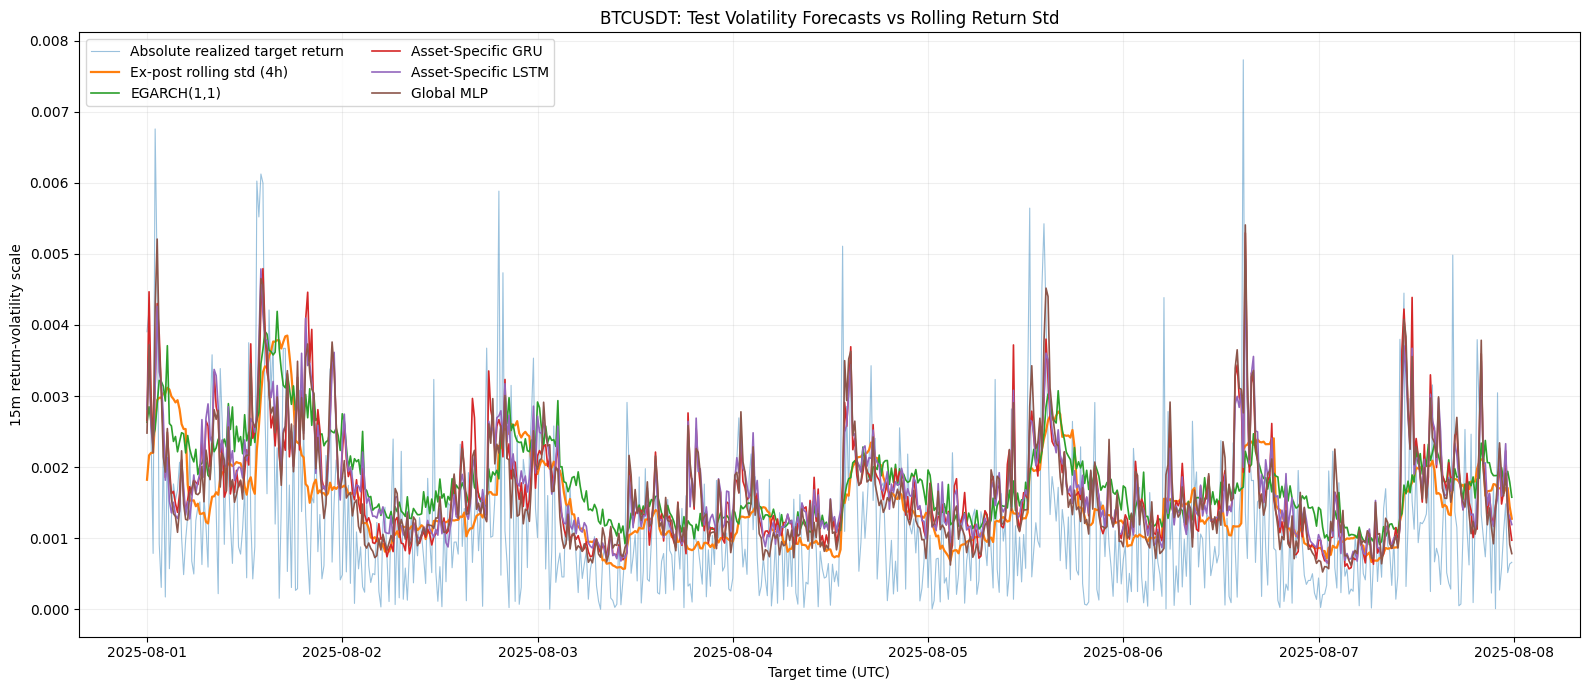

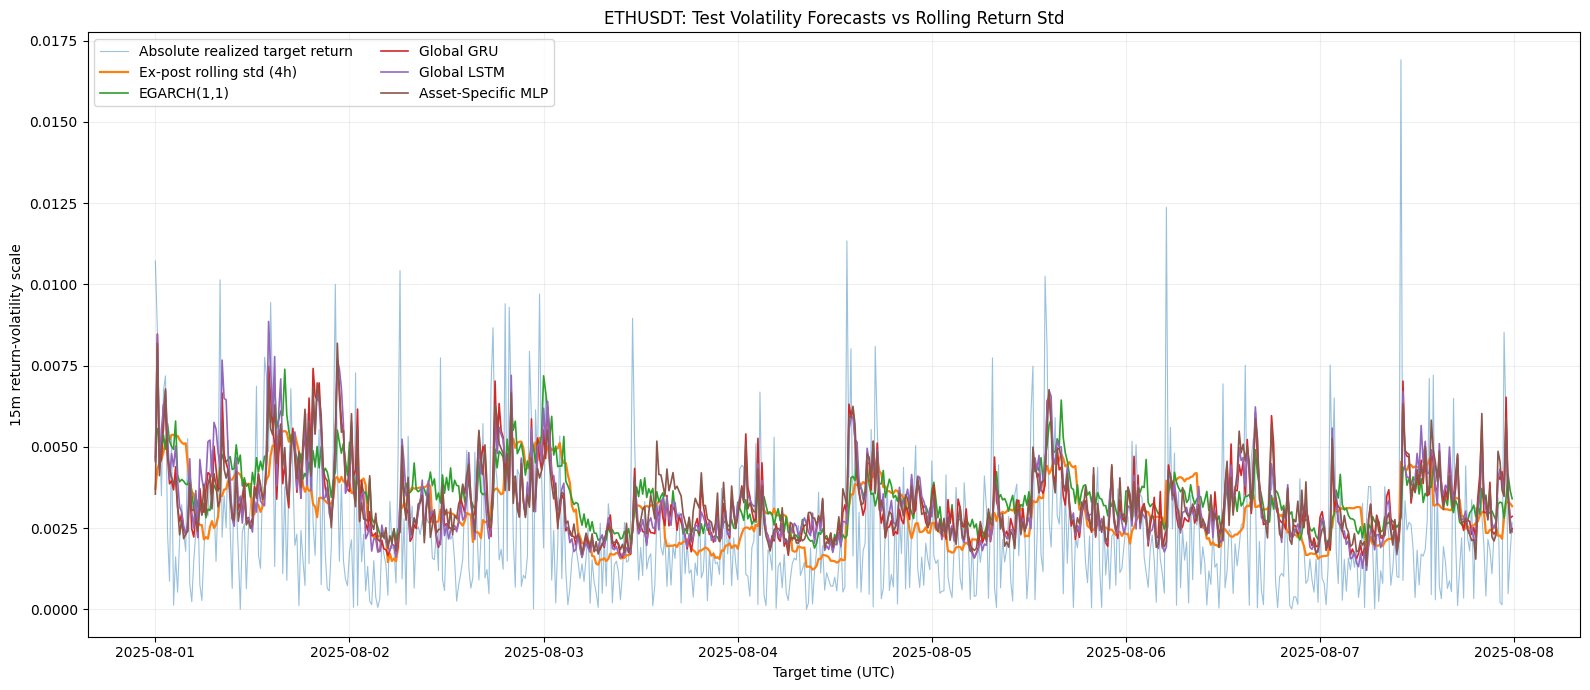

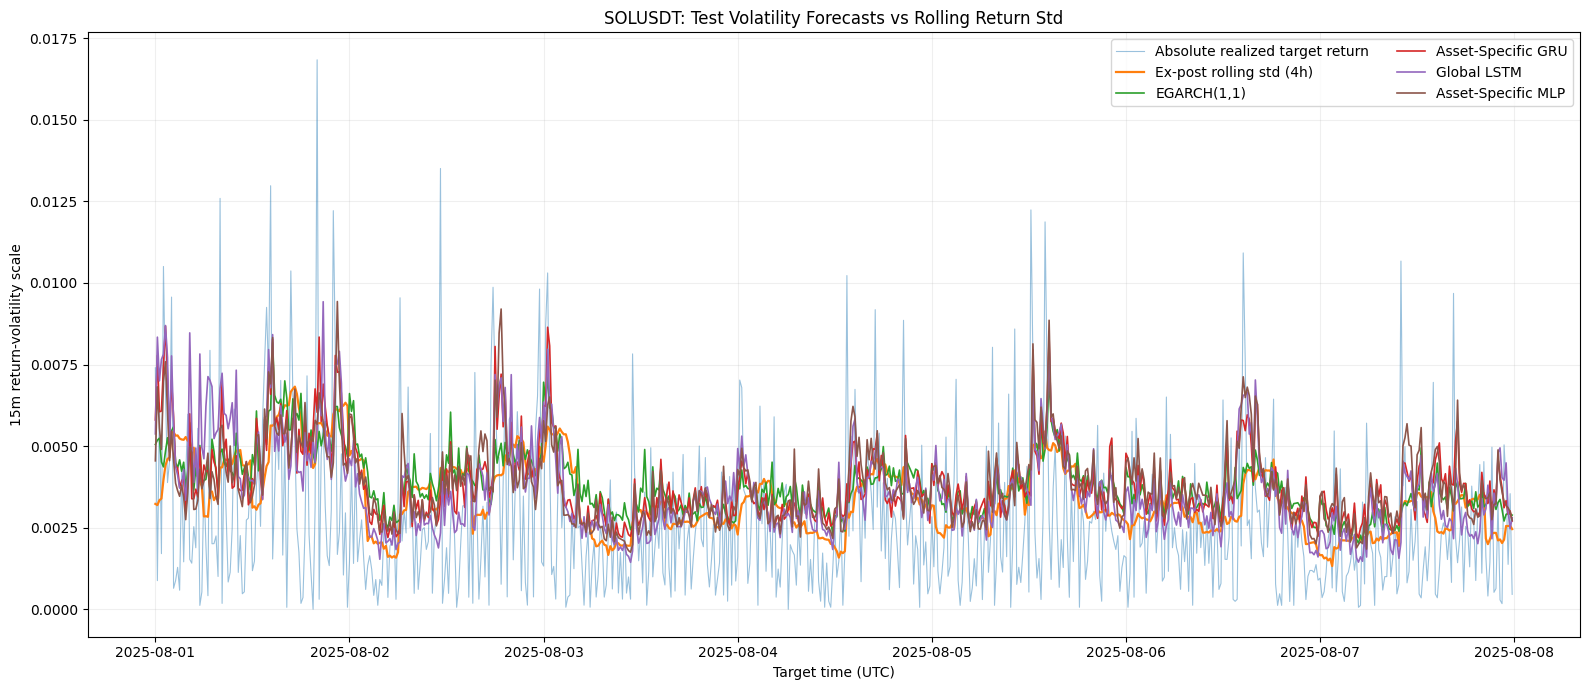

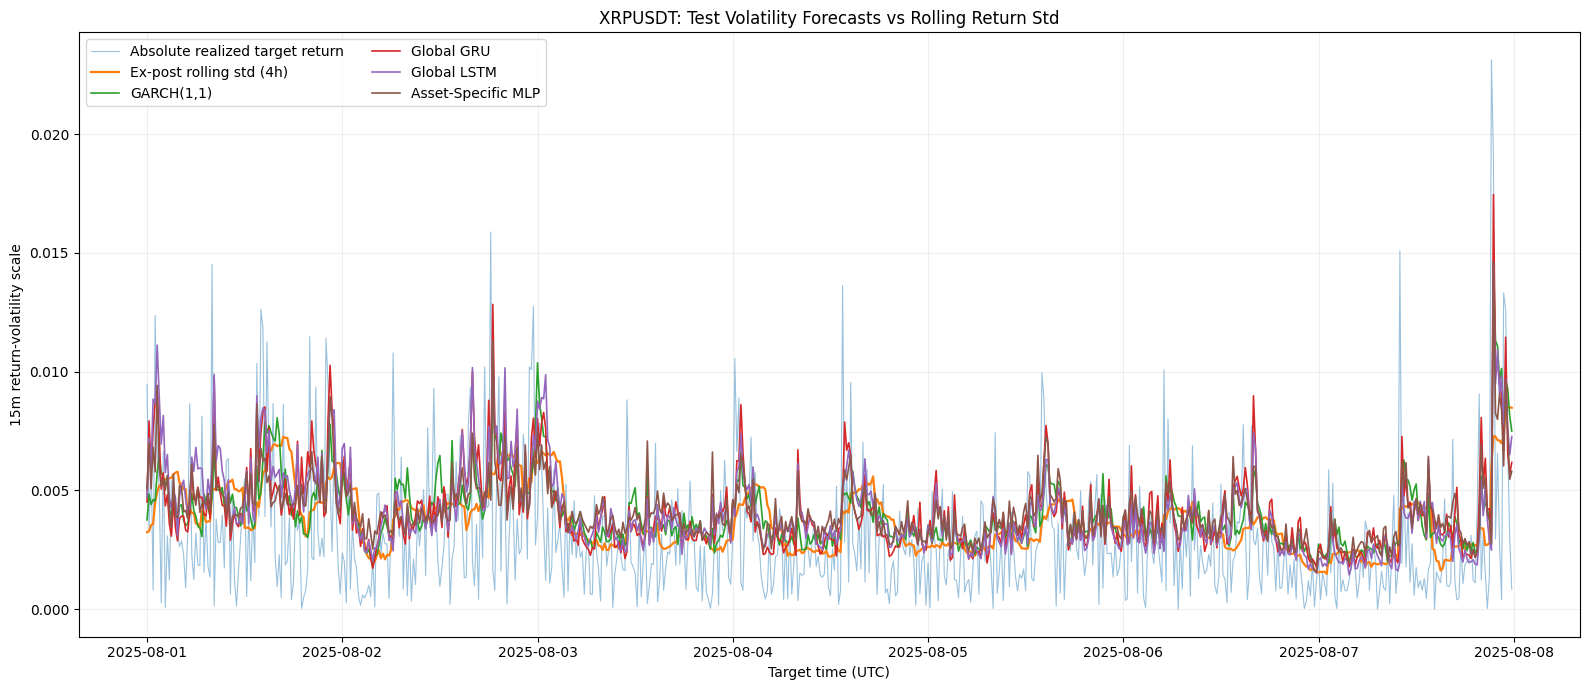

In [36]:
def resolved_plot_start():
    if PLOT_START is None:
        return TEST_START
    return pd.Timestamp(PLOT_START, tz="UTC") if pd.Timestamp(PLOT_START).tzinfo is None else pd.Timestamp(PLOT_START).tz_convert("UTC")


plot_start = resolved_plot_start()
plot_end = min(
    plot_start + pd.Timedelta(PLOT_WINDOW_DURATION),
    TEST_END_EXCLUSIVE,
)

DEFAULT_PROXY_DURATION = ROLLING_PROXY_DURATIONS[0] # 4h, 12h, 24h
DEFAULT_PROXY_COLUMN = f"proxy_std_{duration_tag(DEFAULT_PROXY_DURATION)}"

for symbol in SYMBOLS:
    selected_models = (
        validation_family_winners_df.loc[
            validation_family_winners_df["symbol"].eq(symbol),
            "model",
        ]
        .astype(str)
        .tolist()
    )

    # Do not display rolling-mean-RV baselines in the volatility figure.
    # They remain in all metric tables/comparisons.
    selected_models = [
        model
        for model in selected_models
        if not model.startswith("Mean RV")
    ]

    current = proxy_test_df.loc[
        proxy_test_df["symbol"].eq(symbol)
        & proxy_test_df["target_open_time"].ge(plot_start)
        & proxy_test_df["target_open_time"].lt(plot_end)
        & proxy_test_df["model"].isin(selected_models)
    ].copy()

    if current.empty:
        raise ValueError(f"{symbol}: no Test rows in selected plot window.")

    actual = (
        current[["target_open_time", "actual_variance", DEFAULT_PROXY_COLUMN]]
        .drop_duplicates("target_open_time")
        .sort_values("target_open_time")
    )

    plt.figure(figsize=(16, 7))

    plt.plot(
        actual["target_open_time"],
        np.sqrt(np.maximum(actual["actual_variance"], 0.0)),
        label="Absolute realized target return",
        linewidth=0.8,
        alpha=0.45,
    )

    plt.plot(
        actual["target_open_time"],
        actual[DEFAULT_PROXY_COLUMN],
        label=f"Ex-post rolling std ({DEFAULT_PROXY_DURATION})",
        linewidth=1.6,
    )

    for model_name in selected_models:
        model_rows = (
            current.loc[current["model"].eq(model_name)]
            .sort_values("target_open_time")
        )
        plt.plot(
            model_rows["target_open_time"],
            np.sqrt(model_rows["predicted_variance"]),
            label=model_name,
            linewidth=1.2,
        )

    plt.title(
        f"{symbol}: Test Volatility Forecasts vs Rolling Return Std"
    )
    plt.xlabel("Target time (UTC)")
    plt.ylabel(f"{KLINE_INTERVAL} return-volatility scale")
    plt.legend(ncol=2)
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(
        FIGURE_ROOT / f"{symbol}_test_volatility_vs_rolling_std.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

## 28. QLIKE figures

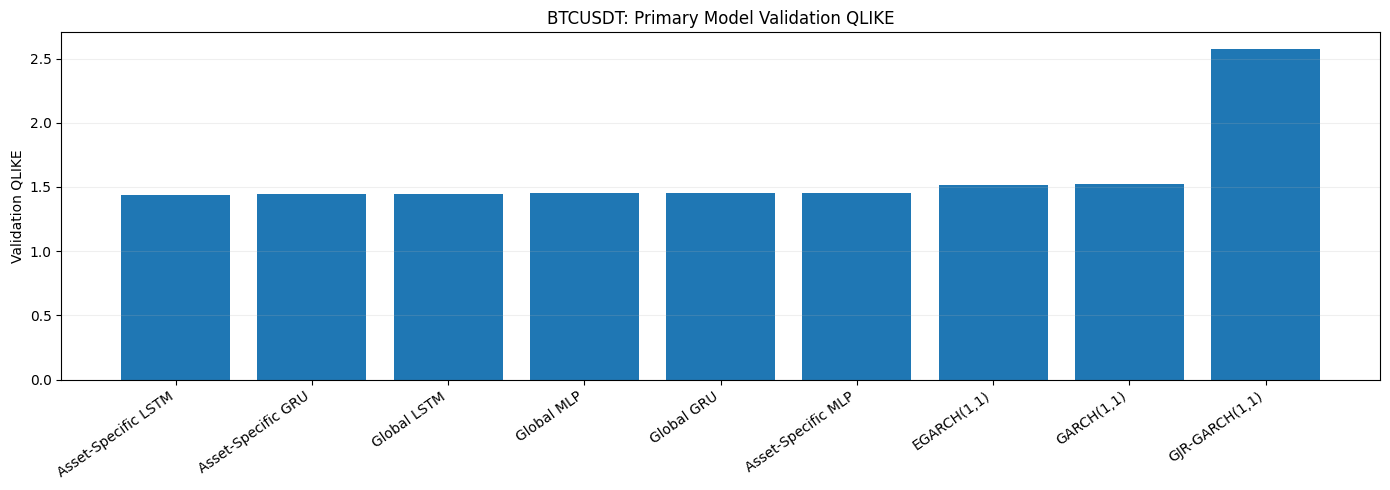

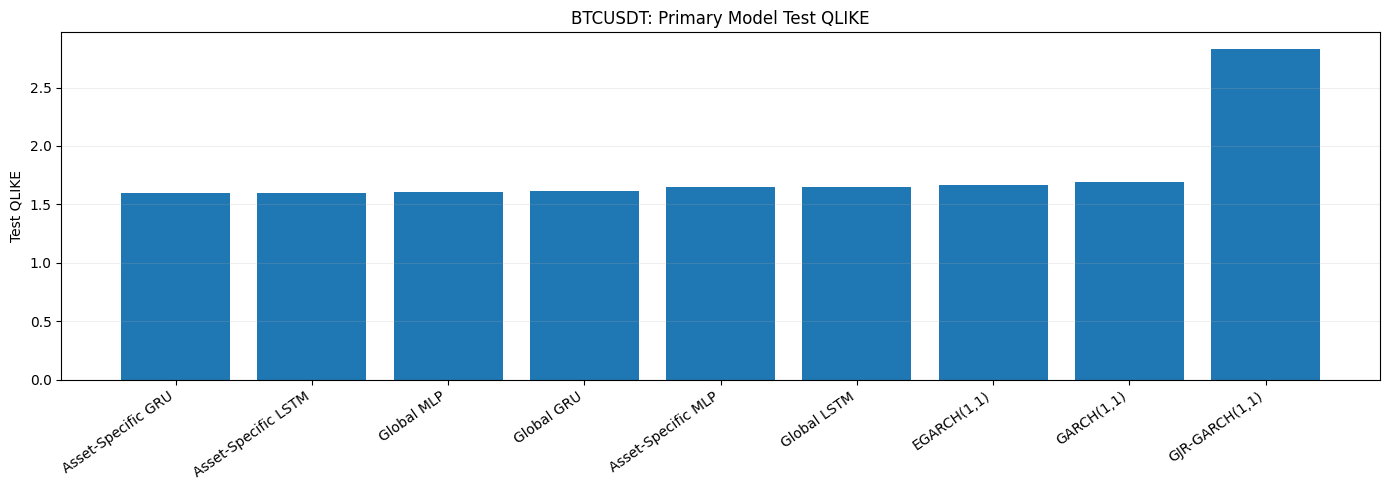

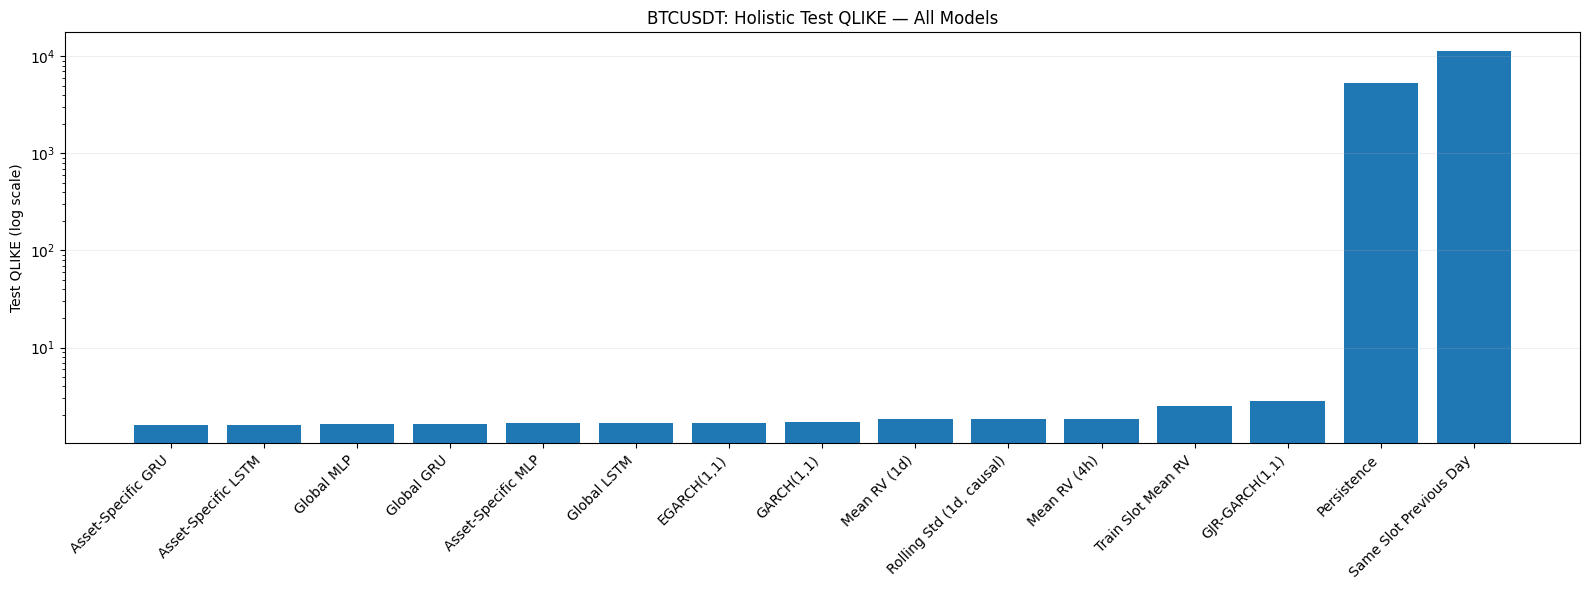

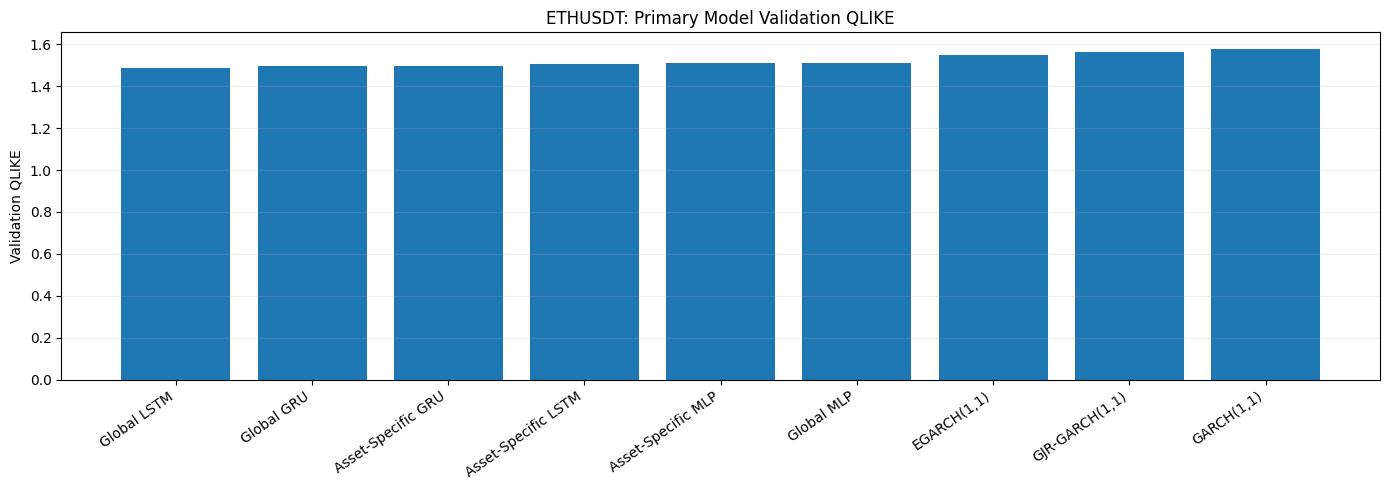

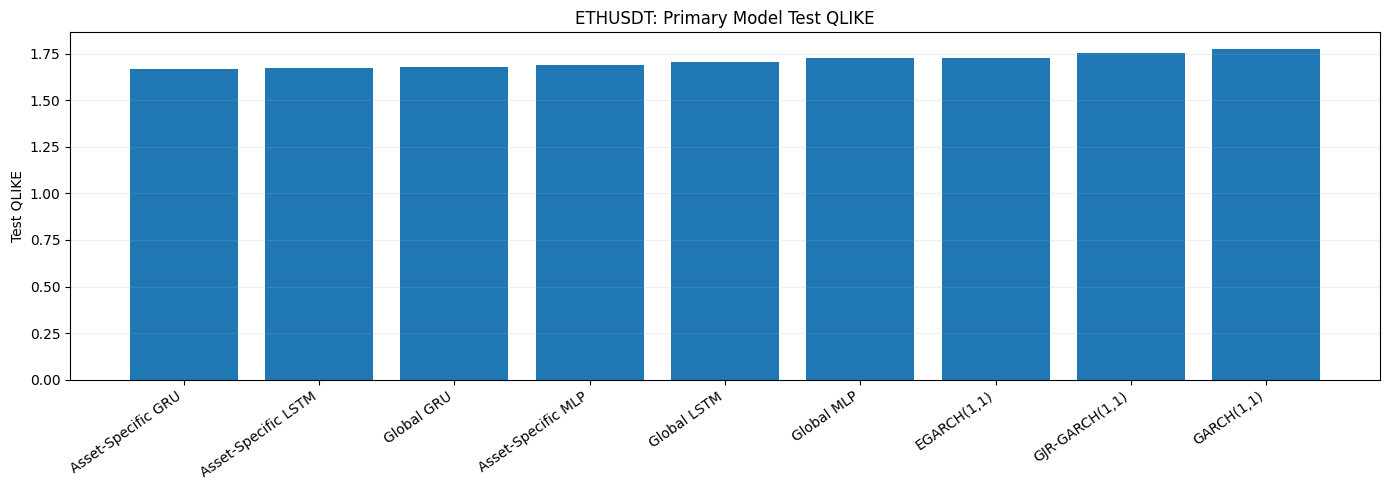

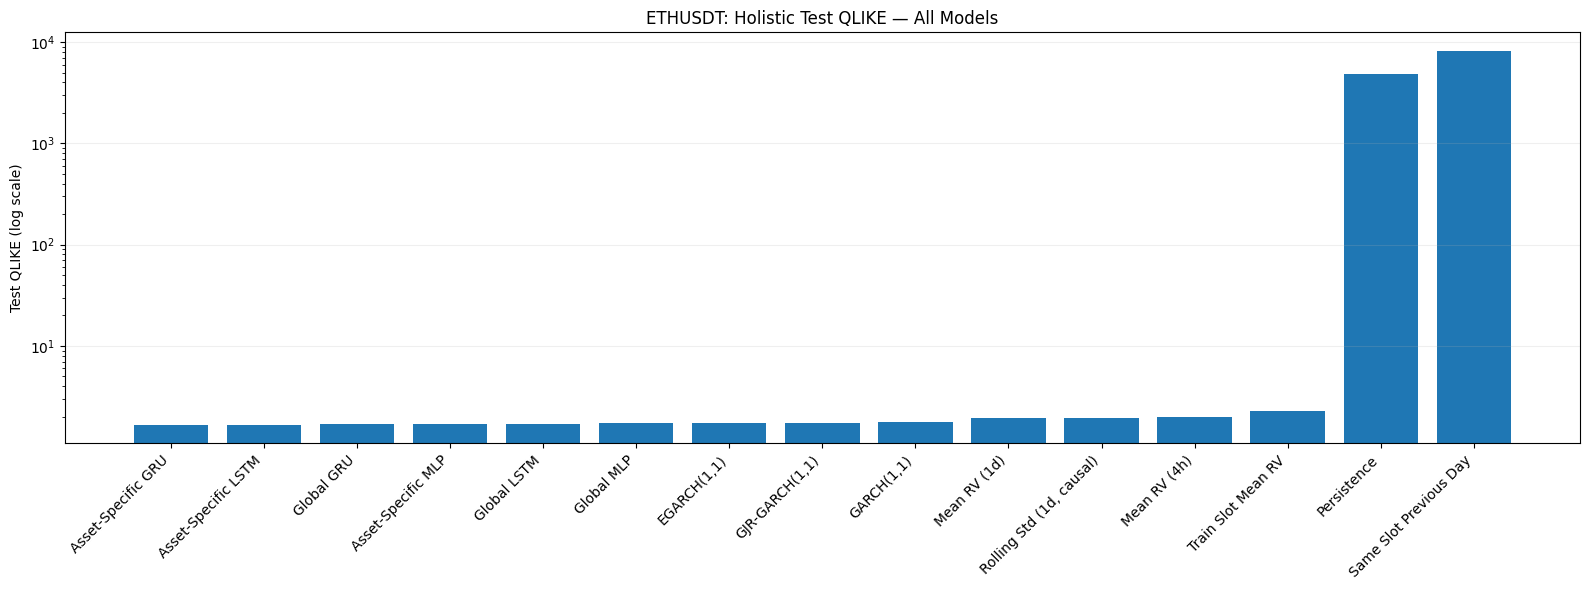

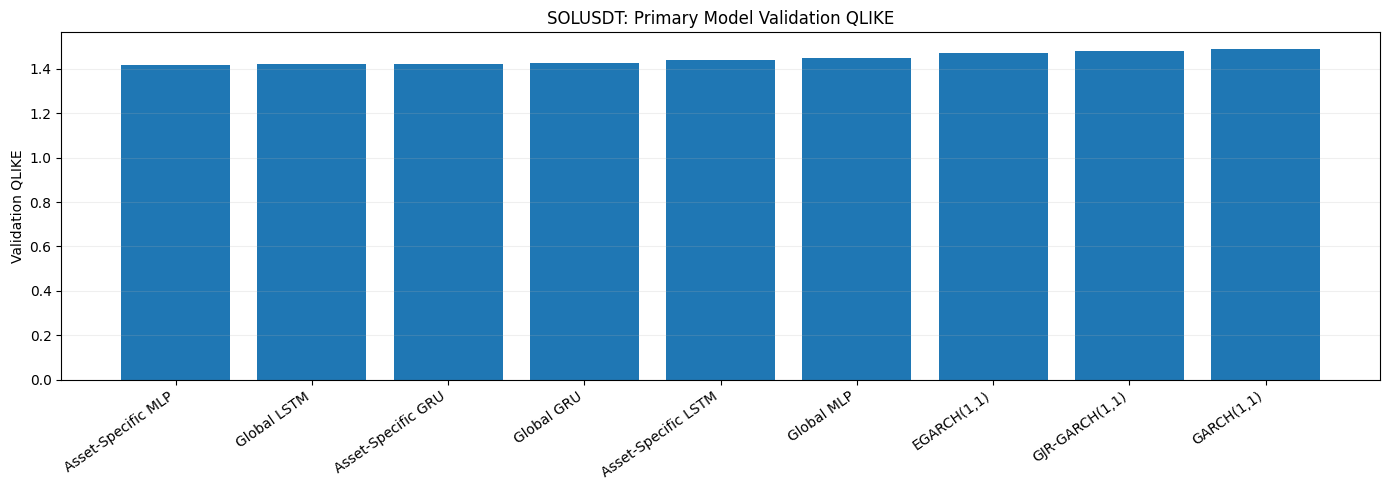

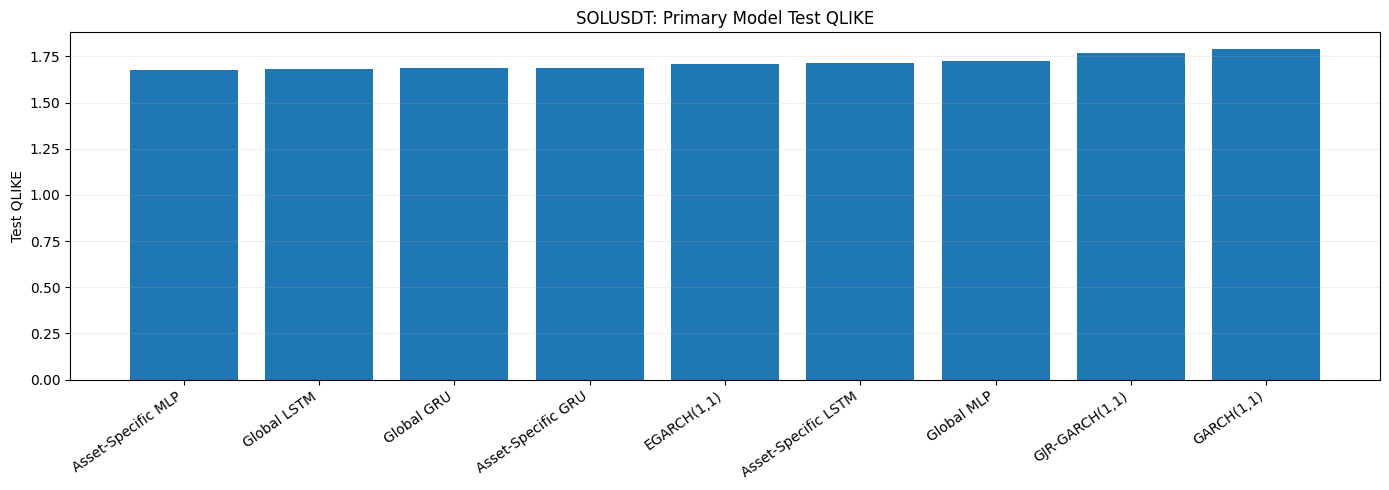

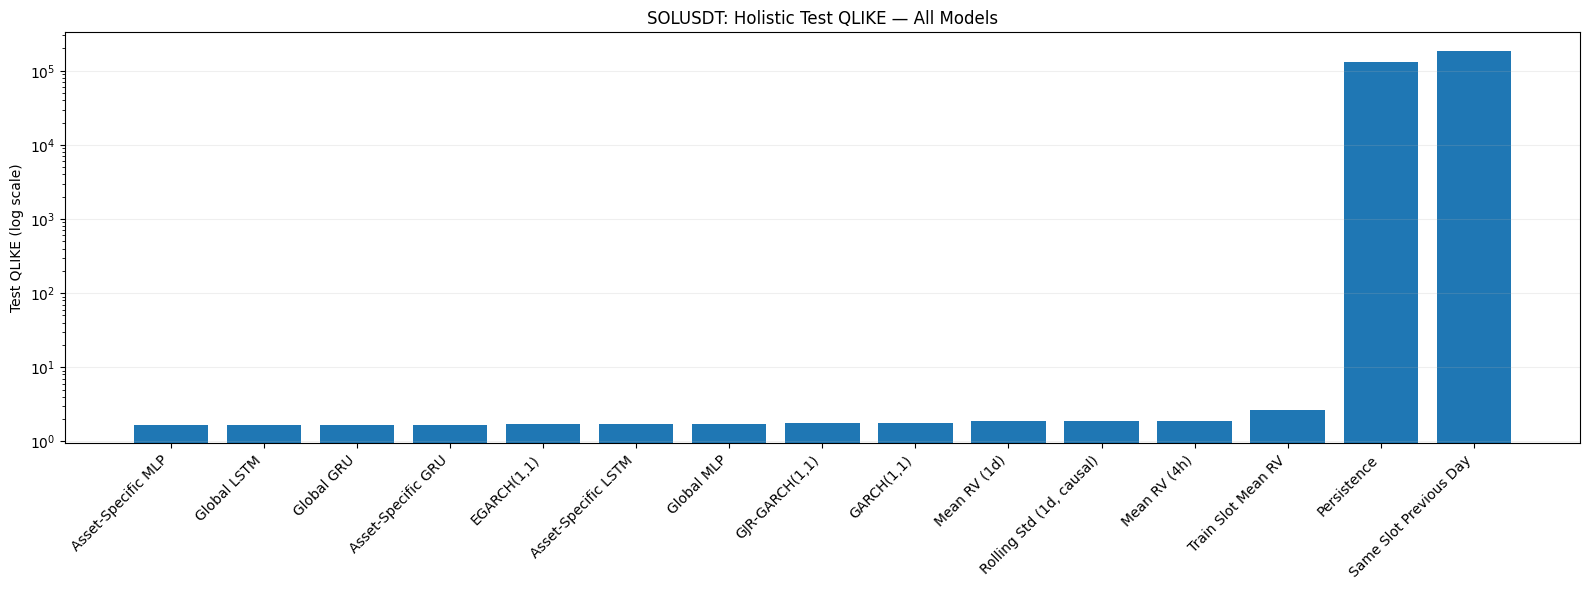

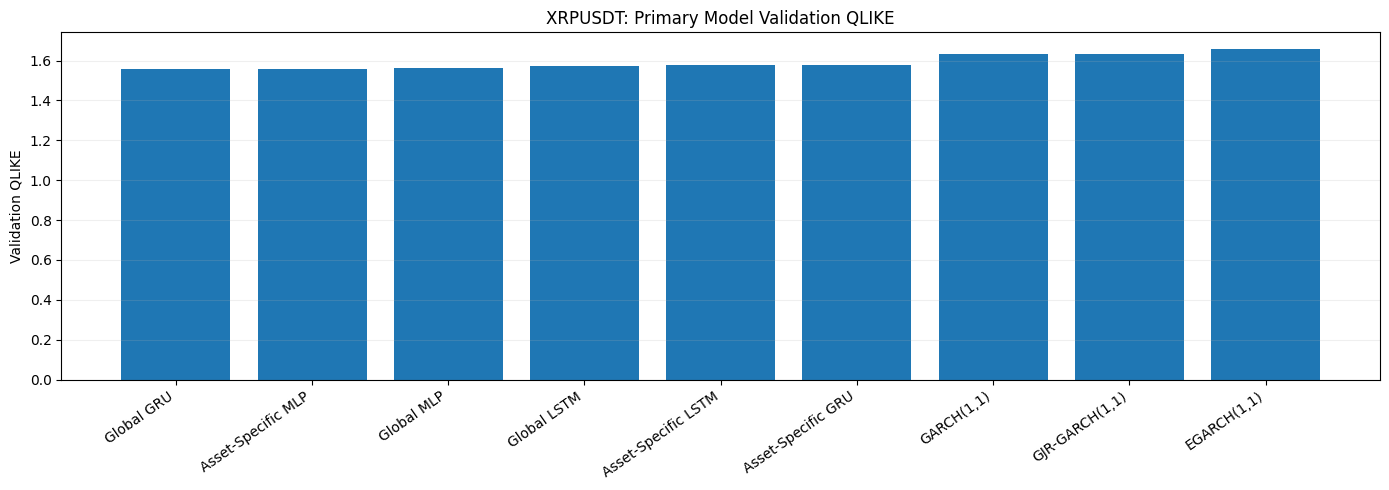

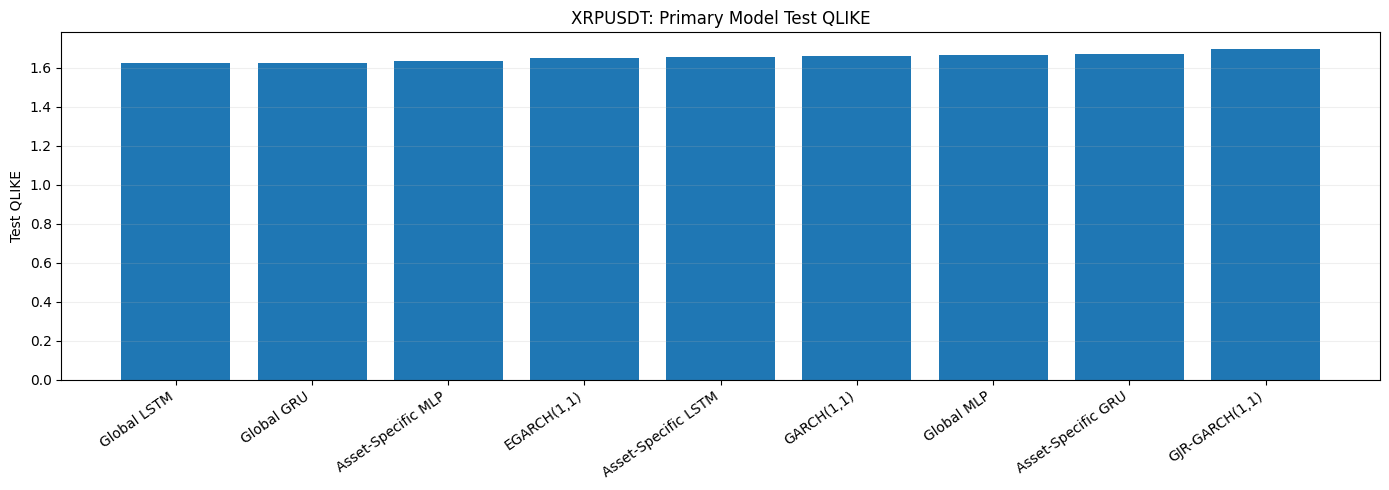

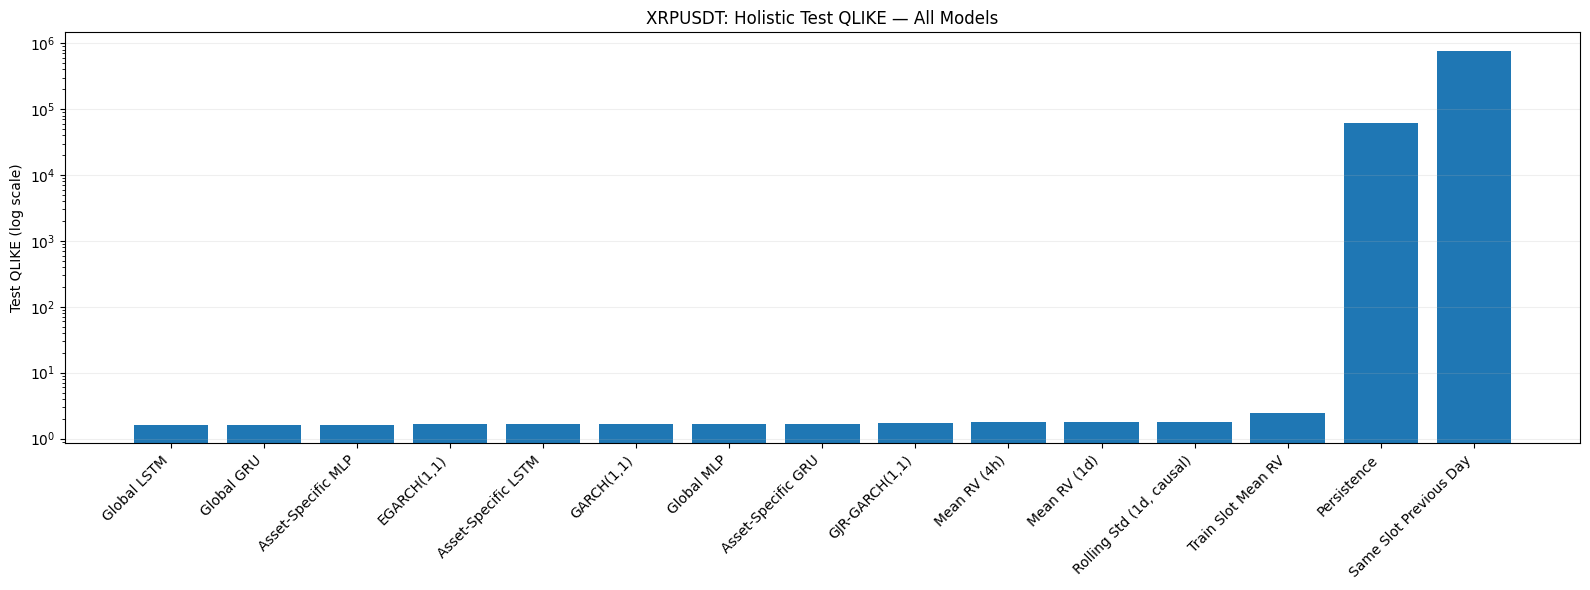

In [28]:
PRIMARY_MODELS = ARCH_MODEL_ORDER + DL_MODEL_ORDER

for symbol in SYMBOLS:
    for split_name in ["Validation", "Test"]:
        x = (
            metrics_long_df.loc[
                metrics_long_df["symbol"].eq(symbol)
                & metrics_long_df["split"].eq(split_name)
                & metrics_long_df["model"].isin(PRIMARY_MODELS)
            ]
            .sort_values("qlike")
        )

        plt.figure(figsize=(14, 5))
        plt.bar(x["model"].astype(str), x["qlike"])
        plt.ylabel(f"{split_name} QLIKE")
        plt.title(f"{symbol}: Primary Model {split_name} QLIKE")
        plt.xticks(rotation=35, ha="right")
        plt.grid(axis="y", alpha=0.2)
        plt.tight_layout()
        plt.savefig(
            FIGURE_ROOT / f"{symbol}_{split_name.lower()}_primary_qlike.png",
            dpi=200,
            bbox_inches="tight",
        )
        plt.show()

    # All models, including high-QLIKE naive baselines; log scale avoids
    # compressing the strong models against persistence-like extremes.
    x_all = (
        metrics_long_df.loc[
            metrics_long_df["symbol"].eq(symbol)
            & metrics_long_df["split"].eq("Test")
        ]
        .sort_values("qlike")
    )

    plt.figure(figsize=(16, 6))
    plt.bar(x_all["model"].astype(str), x_all["qlike"])
    plt.yscale("log")
    plt.ylabel("Test QLIKE (log scale)")
    plt.title(f"{symbol}: Holistic Test QLIKE — All Models")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.savefig(
        FIGURE_ROOT / f"{symbol}_test_all_models_qlike_log.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

## 29. Train / Validation / Test QLIKE generalization plots

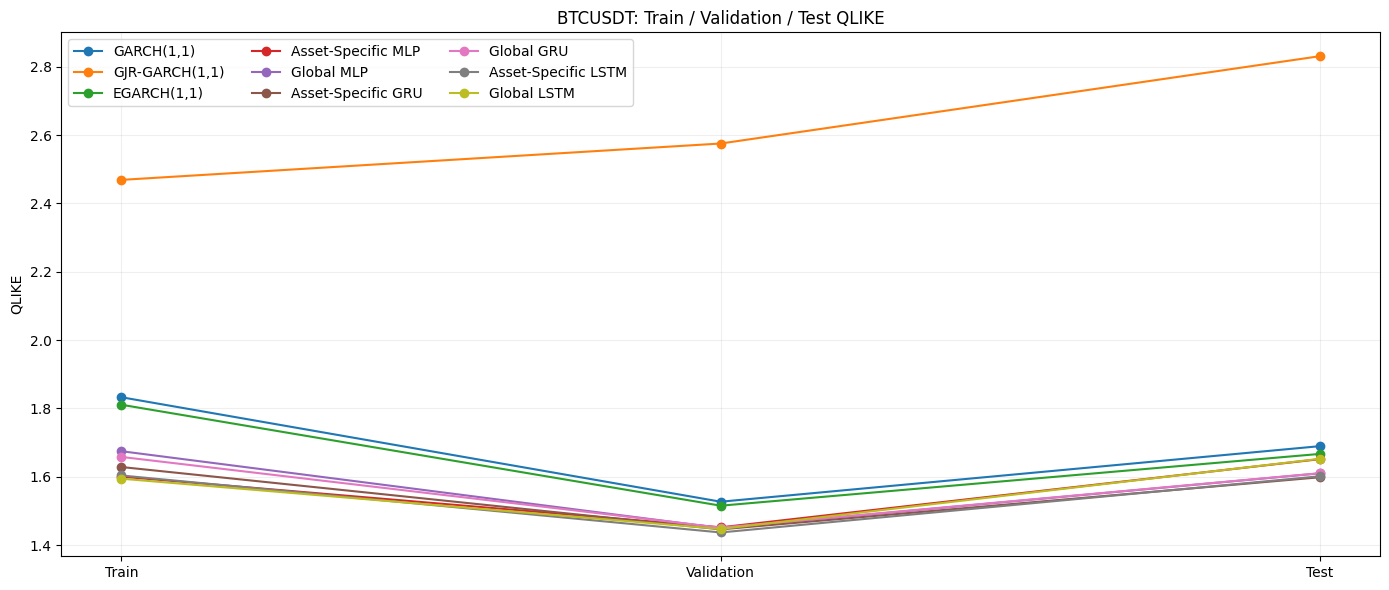

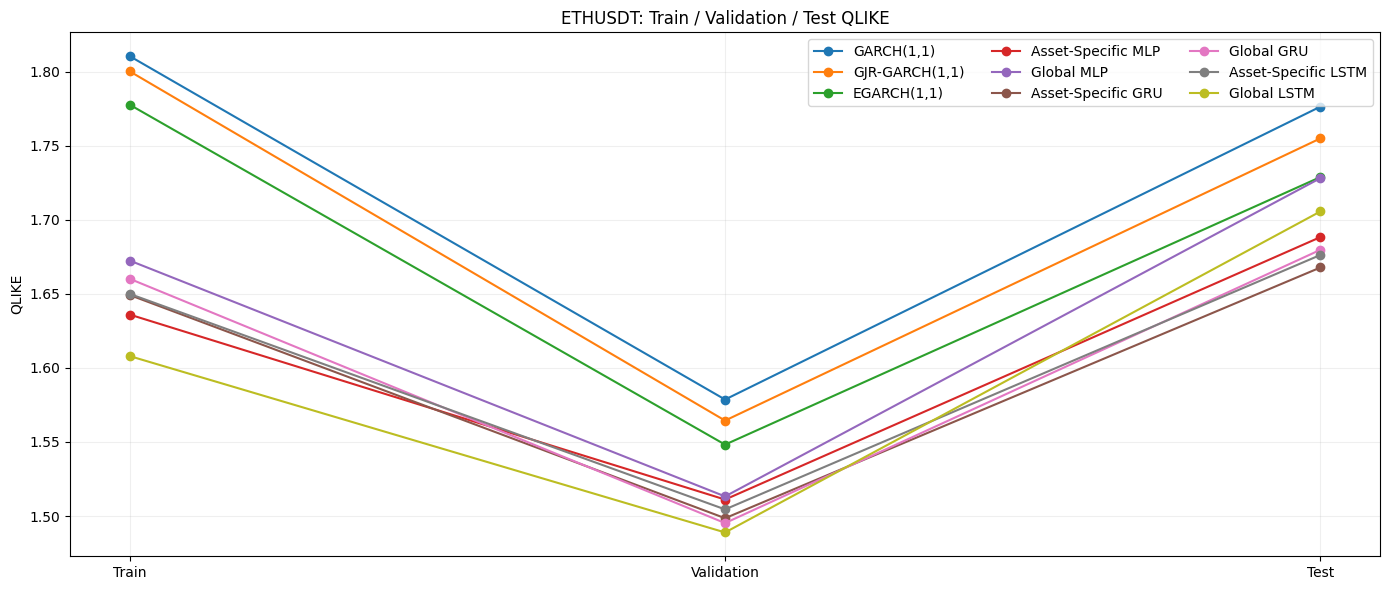

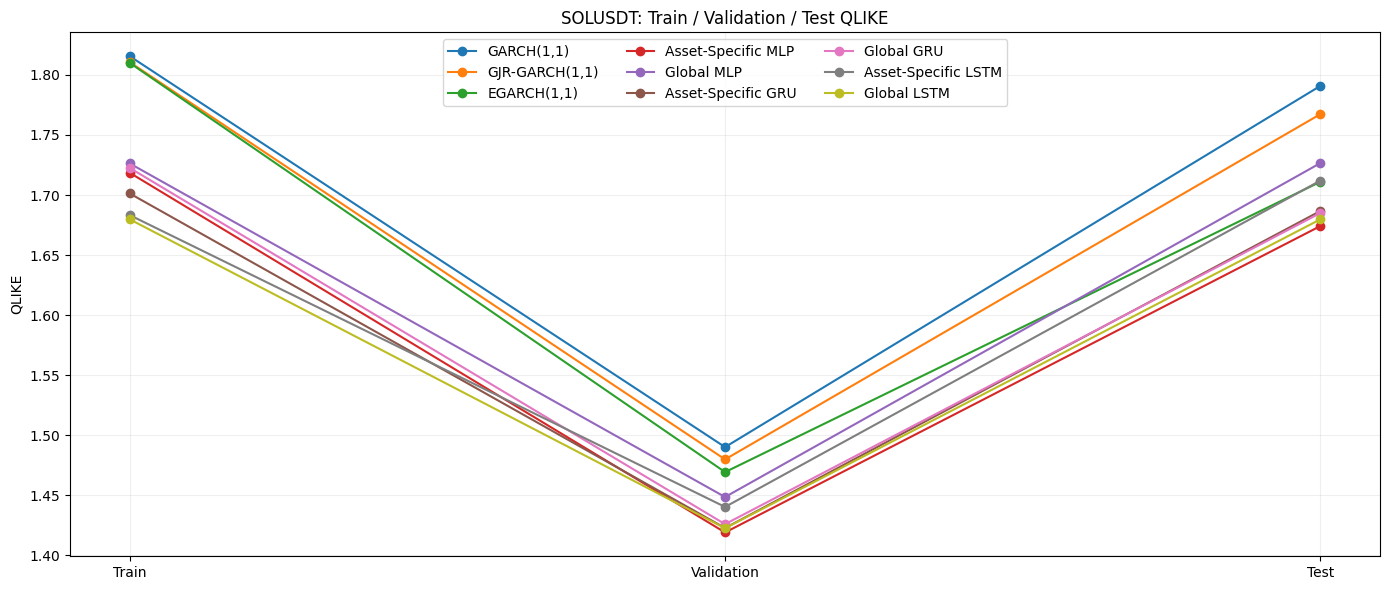

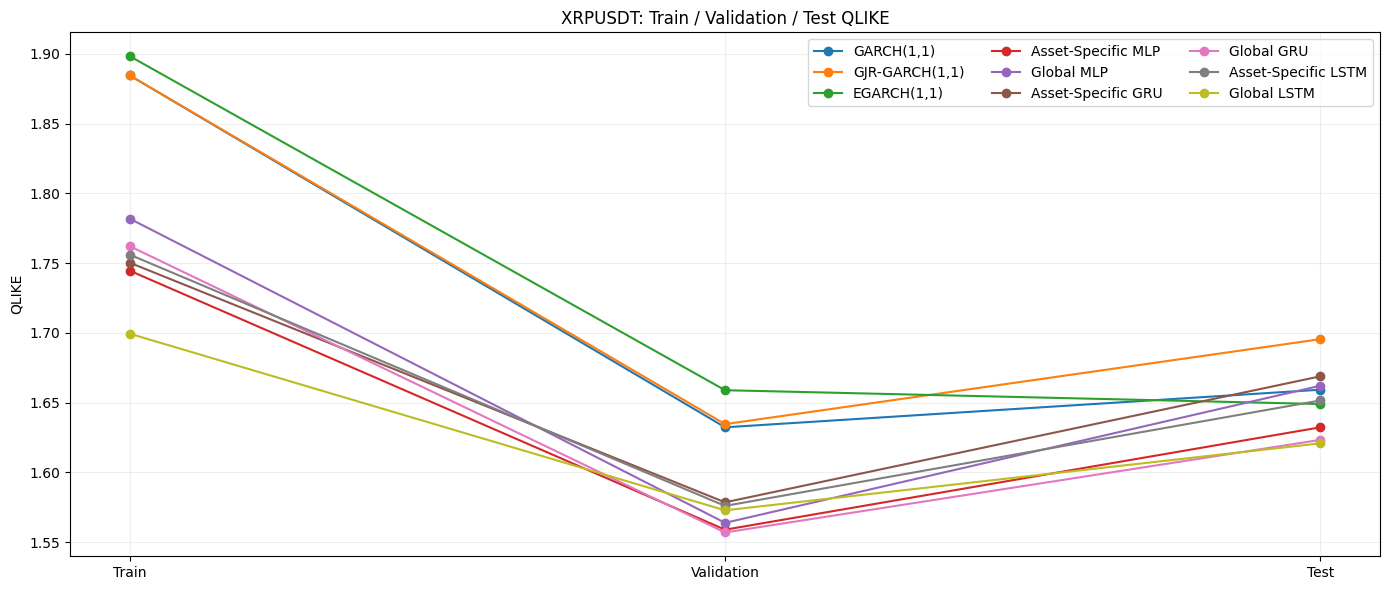

In [29]:
for symbol in SYMBOLS:
    x = metrics_long_df.loc[
        metrics_long_df["symbol"].eq(symbol)
        & metrics_long_df["model"].isin(PRIMARY_MODELS)
    ].copy()

    plt.figure(figsize=(14, 6))

    for model_name in PRIMARY_MODELS:
        current = (
            x.loc[x["model"].eq(model_name)]
            .sort_values("split")
        )
        plt.plot(
            current["split"].astype(str),
            current["qlike"],
            marker="o",
            label=model_name,
        )

    plt.ylabel("QLIKE")
    plt.title(f"{symbol}: Train / Validation / Test QLIKE")
    plt.grid(alpha=0.2)
    plt.legend(ncol=3)
    plt.tight_layout()
    plt.savefig(
        FIGURE_ROOT / f"{symbol}_train_validation_test_qlike.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

## 30. Save final metrics, predictions, robustness outputs and manifest

In [30]:
METRICS_LONG_PATH = (
    FINAL_RESULTS_ROOT
    / "all_models_train_validation_test_metrics_long.csv"
)
COMMON_DATE_PATH = (
    FINAL_RESULTS_ROOT
    / "common_evaluation_date_qc.csv"
)
QLIKE_PATH = (
    FINAL_RESULTS_ROOT
    / "QLIKE_train_validation_test.csv"
)
RMSE_PATH = (
    FINAL_RESULTS_ROOT
    / "RMSE_train_validation_test.csv"
)
MAE_PATH = (
    FINAL_RESULTS_ROOT
    / "MAE_train_validation_test.csv"
)
VALIDATION_RANKING_PATH = (
    FINAL_RESULTS_ROOT
    / "validation_ranking_all_models.csv"
)
TEST_RANKING_PATH = (
    FINAL_RESULTS_ROOT
    / "test_ranking_all_models.csv"
)
GENERALIZATION_PATH = (
    FINAL_RESULTS_ROOT
    / "generalization_gap_metrics.csv"
)
ROLLING_PROXY_PATH = (
    FINAL_RESULTS_ROOT
    / "rolling_std_proxy_test_metrics.csv"
)
TEST_PREDICTIONS_PATH = (
    FINAL_RESULTS_ROOT
    / "test_predictions_all_models.parquet"
)
ARCH_DIAGNOSTICS_PATH = (
    FINAL_RESULTS_ROOT
    / "arch_refit_diagnostics.csv"
)
MANIFEST_PATH = (
    FINAL_RESULTS_ROOT
    / "final_evaluation_manifest.json"
)

metrics_long_df.to_csv(METRICS_LONG_PATH, index=False)
common_date_qc_df.to_csv(COMMON_DATE_PATH, index=False)
QLIKE_TABLE.to_csv(QLIKE_PATH)
RMSE_TABLE.to_csv(RMSE_PATH)
MAE_TABLE.to_csv(MAE_PATH)
validation_ranking_df.to_csv(VALIDATION_RANKING_PATH, index=False)
test_ranking_df.to_csv(TEST_RANKING_PATH, index=False)
generalization_gap_df.to_csv(GENERALIZATION_PATH, index=False)
rolling_proxy_test_metrics_df.to_csv(ROLLING_PROXY_PATH, index=False)
arch_diagnostics_df.to_csv(ARCH_DIAGNOSTICS_PATH, index=False)

test_predictions_df.to_parquet(
    TEST_PREDICTIONS_PATH,
    index=False,
    compression="zstd",
)

final_manifest = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "kline_interval": KLINE_INTERVAL,
    "interval_minutes": INTERVAL_MINUTES,
    "forecast_target": "next_candle_squared_close_to_close_log_return",
    "primary_metric": "QLIKE",
    "supporting_metrics": ["MAE", "RMSE"],
    "validation_start": VALIDATION_START.isoformat(),
    "test_start": TEST_START.isoformat(),
    "test_end_exclusive": TEST_END_EXCLUSIVE.isoformat(),
    "causal_rolling_std_baseline_duration": ROLLING_STD_BASELINE_DURATION,
    "expost_rolling_std_proxy_durations": ROLLING_PROXY_DURATIONS,
    "gru_lookback_duration": GRU_LOOKBACK_DURATION,
    "gru_lookback_bars": GRU_LOOKBACK_BARS,
    "lstm_lookback_duration": LSTM_LOOKBACK_DURATION,
    "lstm_lookback_bars": LSTM_LOOKBACK_BARS,
    "mlp_feature_count": len(MLP_FEATURE_COLUMNS),
    "models": MODEL_ORDER,
    "validation_reproduction_gate_passed": True,
    "test_evaluated": True,
    "post_test_tuning_allowed": False,
}

MANIFEST_PATH.write_text(
    json.dumps(final_manifest, indent=2),
    encoding="utf-8",
)

print("Saved final outputs:")
for path in [
    METRICS_LONG_PATH,
    COMMON_DATE_PATH,
    QLIKE_PATH,
    RMSE_PATH,
    MAE_PATH,
    VALIDATION_RANKING_PATH,
    TEST_RANKING_PATH,
    GENERALIZATION_PATH,
    ROLLING_PROXY_PATH,
    TEST_PREDICTIONS_PATH,
    ARCH_DIAGNOSTICS_PATH,
    MANIFEST_PATH,
]:
    print(" -", path)

Saved final outputs:
 - /content/drive/MyDrive/Quant Research/15min/results/15m/FINAL_HOLISTIC_COMPARISON/all_models_train_validation_test_metrics_long.csv
 - /content/drive/MyDrive/Quant Research/15min/results/15m/FINAL_HOLISTIC_COMPARISON/common_evaluation_date_qc.csv
 - /content/drive/MyDrive/Quant Research/15min/results/15m/FINAL_HOLISTIC_COMPARISON/QLIKE_train_validation_test.csv
 - /content/drive/MyDrive/Quant Research/15min/results/15m/FINAL_HOLISTIC_COMPARISON/RMSE_train_validation_test.csv
 - /content/drive/MyDrive/Quant Research/15min/results/15m/FINAL_HOLISTIC_COMPARISON/MAE_train_validation_test.csv
 - /content/drive/MyDrive/Quant Research/15min/results/15m/FINAL_HOLISTIC_COMPARISON/validation_ranking_all_models.csv
 - /content/drive/MyDrive/Quant Research/15min/results/15m/FINAL_HOLISTIC_COMPARISON/test_ranking_all_models.csv
 - /content/drive/MyDrive/Quant Research/15min/results/15m/FINAL_HOLISTIC_COMPARISON/generalization_gap_metrics.csv
 - /content/drive/MyDrive/Quant R

## 31. Final end-to-end QC

In [31]:
expected_metric_rows = (
    len(SYMBOLS)
    * len(MODEL_ORDER)
    * 3
)

if len(metrics_long_df) != expected_metric_rows:
    raise ValueError(
        f"Metric row count {len(metrics_long_df)} != expected {expected_metric_rows}."
    )

# Every model must use exactly the same evaluation-date count within each
# asset / split.
count_qc = (
    metrics_long_df
    .groupby(["symbol", "split"], observed=True)["n_observations"]
    .nunique()
)
assert count_qc.eq(1).all()

# Test prediction keys must be unique.
assert not test_predictions_df.duplicated(
    ["symbol", "target_open_time", "model"]
).any()

assert np.isfinite(
    test_predictions_df["predicted_variance"].to_numpy(dtype=float)
).all()
assert test_predictions_df["predicted_variance"].gt(0).all()

assert np.isfinite(
    metrics_long_df[["mae", "rmse", "qlike"]].to_numpy(dtype=float)
).all()
assert metrics_long_df["qlike"].ge(-1e-12).all()

# Validation must still be exactly the saved official range.
validation_metrics = metrics_long_df.loc[
    metrics_long_df["split"].eq("Validation")
]
assert validation_metrics["n_observations"].eq(EXPECTED_VALIDATION_ROWS).all()

# Test uses the dynamically constructed common sample. If the upstream data
# are complete this equals EXPECTED_TEST_ROWS; if a future source has a gap,
# the common-date table documents the reduced fair sample instead of silently
# comparing models on different dates.
test_common = common_date_qc_df.loc[
    common_date_qc_df["split"].eq("test")
]

if test_common["observations"].eq(EXPECTED_TEST_ROWS).all():
    print("Test has complete canonical coverage.")
else:
    warnings.warn(
        "Test common sample is smaller than the theoretical full grid. "
        "All models are still compared on identical dates; inspect common_evaluation_date_qc.csv."
    )

# All saved files should exist.
for path in [
    METRICS_LONG_PATH,
    COMMON_DATE_PATH,
    QLIKE_PATH,
    RMSE_PATH,
    MAE_PATH,
    VALIDATION_RANKING_PATH,
    TEST_RANKING_PATH,
    GENERALIZATION_PATH,
    ROLLING_PROXY_PATH,
    TEST_PREDICTIONS_PATH,
    MANIFEST_PATH,
]:
    assert path.exists()

print("\nALL FINAL INTRADAY HOLISTIC COMPARISON QC CHECKS PASSED.")
print("Validation reproduction gate: PASSED")
print("Held-out Test: EVALUATED")
print("\nIMPORTANT: do not tune these frozen models after reading Test results.")

Test has complete canonical coverage.

ALL FINAL INTRADAY HOLISTIC COMPARISON QC CHECKS PASSED.
Validation reproduction gate: PASSED
Held-out Test: EVALUATED

IMPORTANT: do not tune these frozen models after reading Test results.


# Paper interpretation guide

Use the outputs in this order:

1. **Validation ranking** — documents the model-development conclusion before Test was opened.
2. **Test ranking** — the true final generalization result.
3. **Train / Validation / Test tables** — diagnose generalization; remember that Train error is in-sample for fitted models and is not itself an out-of-sample performance claim.
4. **Causal rolling-std baseline** — a legitimate predictive benchmark because it uses only information through the forecast origin.
5. **Ex-post rolling-std proxy** — a robustness reference showing how the frozen next-candle forecasts relate to smoother realized historical volatility. It is not a forecast target used during training.

After this notebook, the current 15-minute experiment should be treated as methodologically closed.